# CARDIOVASCULAR DISEASE PREDICTION - MEDICAL ANALYSIS

## Dataset: Cardiovascular Disease Dataset
**Kaynak:** https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset

## Proje Hedefi: KARDIYOVASKULER HASTALIK RISK TAHMINI

## Proje Ozellikleri:
- **Medical EDA** - 20+ health-focused visualizations
- **Risk Factor Analysis** - Blood pressure, cholesterol, BMI
- **15+ ML Models** - Classification with medical metrics
- **Clinical Feature Engineering** - Medical-specific features
- **Comprehensive Comparison** - 7-part visual analysis
- **SMOTE** - Class imbalance handling
- **Medical Metrics** - Sensitivity, Specificity, PPV, NPV
- **Clinical Insights** - Actionable recommendations

## Proje Adimlari:
1. Veri Yukleme & Medical Structure
2. MEDICAL EDA (20+ health graphs)
3. Risk Factor Analysis
4. Clinical Feature Engineering
5. 15+ ML Models (Medical metrics)
6. 7-Part Comprehensive Comparison
7. Clinical Insights & Recommendations

## 1. KUTUPHANELER

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os
import subprocess
import zipfile
import glob

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Install catboost if not already installed
try:
    import catboost
except ImportError:
    !pip install catboost
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY = True
except:
    PLOTLY = False

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('='*80)
print('CARDIOVASCULAR DISEASE ANALYSIS - KUTUPHANELER YUKLENDI')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Plotly: {"Available" if PLOTLY else "Not Available"}')
print('='*80)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.4 MB/s eta 0:00:00
CARDIOVASCULAR DISEASE ANALYSIS - KUTUPHANELER YUKLENDI
NumPy: 2.0.2
Pandas: 2.2.2
Plotly: Available


## 2. VERI YUKLEME

In [2]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"Indiriliyor: {zip_filename}")
    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [3]:
dataset_folder = "cardiovascular_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/sulianova/cardiovascular-disease-dataset",
    "folder": dataset_folder,
    "zip_filename": "cardiovascular.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

Indiriliyor: cardiovascular.zip


In [4]:
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0], delimiter=';')  # CSV may use semicolon

    print('='*80)
    print('VERI YUKLENDI')
    print('='*80)
    print(f'Toplam Hasta: {len(df):,}')
    print(f'Sutun Sayisi: {len(df.columns)}')
    print(f'Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*80)
else:
    print('CSV bulunamadi!')

VERI YUKLENDI
Toplam Hasta: 70,000
Sutun Sayisi: 13
Bellek: 6.94 MB


In [5]:
print('ILK 10 KAYIT:')
df.head(10)

ILK 10 KAYIT:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0000,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0000,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0000,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0000,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0000,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0000,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0000,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0000,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0000,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0000,110,60,1,1,0,0,0,0


In [6]:
print('VERI YAPISI:')
print('='*80)
df.info()

VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
print('ISTATISTIKSEL OZET:')
print('='*80)
df.describe().T

ISTATISTIKSEL OZET:


,count,mean,std,min,25%,50%,75%,max
id,70000.0000,49972.4199,28851.3023,0.0000,25006.7500,50001.5000,74889.2500,99999.0000
age,70000.0000,19468.8658,2467.2517,10798.0000,17664.0000,19703.0000,21327.0000,23713.0000
gender,70000.0000,1.3496,0.4768,1.0000,1.0000,1.0000,2.0000,2.0000
height,70000.0000,164.3592,8.2101,55.0000,159.0000,165.0000,170.0000,250.0000
weight,70000.0000,74.2057,14.3958,10.0000,65.0000,72.0000,82.0000,200.0000
ap_hi,70000.0000,128.8173,154.0114,-150.0000,120.0000,120.0000,140.0000,16020.0000
ap_lo,70000.0000,96.6304,188.4725,-70.0000,80.0000,80.0000,90.0000,11000.0000
cholesterol,70000.0000,1.3669,0.6803,1.0000,1.0000,1.0000,2.0000,3.0000
gluc,70000.0000,1.2265,0.5723,1.0000,1.0000,1.0000,1.0000,3.0000
smoke,70000.0000,0.0881,0.2835,0.0000,0.0000,0.0000,0.0000,1.0000


In [8]:
print('SUTUN ISIMLERI:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. {col}')

SUTUN ISIMLERI:
 1. id
 2. age
 3. gender
 4. height
 5. weight
 6. ap_hi
 7. ap_lo
 8. cholesterol
 9. gluc
10. smoke
11. alco
12. active
13. cardio


## 3. MEDICAL EDA - CARDIOVASCULAR INSIGHTS

### Hedef Degisken - Cardiovascular Disease

HEDEF DEGISKEN: cardio
Dagilim:
cardio
0    35021
1    34979
Name: count, dtype: int64

Yuzde:
cardio
0   50.0300
1   49.9700
Name: proportion, dtype: float64


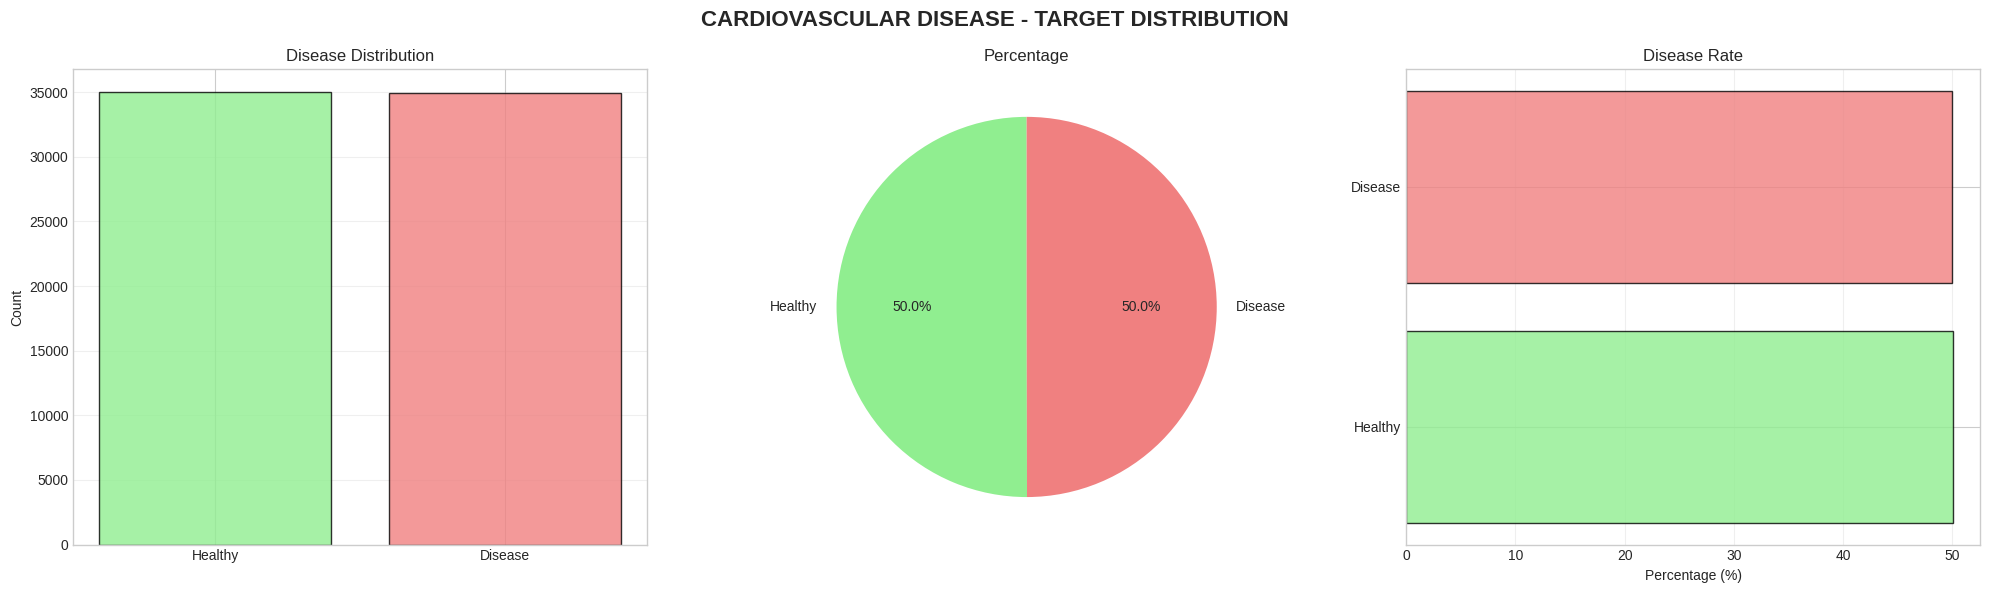


CARDIOVASCULAR DISEASE RATE: 49.97%


In [9]:
# Target variable
target_cols = [col for col in df.columns if 'cardio' in col.lower() or 'disease' in col.lower() or 'target' in col.lower()]
target_col = target_cols[0] if target_cols else df.columns[-1]

print('='*80)
print(f'HEDEF DEGISKEN: {target_col}')
print('='*80)
print('Dagilim:')
print(df[target_col].value_counts())
print('\nYuzde:')
print(df[target_col].value_counts(normalize=True) * 100)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('CARDIOVASCULAR DISEASE - TARGET DISTRIBUTION', fontsize=16, fontweight='bold')

counts = df[target_col].value_counts()
axes[0].bar(range(len(counts)), counts.values,
           color=['lightgreen', 'lightcoral'], edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(['Healthy', 'Disease'])
axes[0].set_ylabel('Count')
axes[0].set_title('Disease Distribution')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(counts.values, labels=['Healthy', 'Disease'],
           autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
axes[1].set_title('Percentage')

pct = df[target_col].value_counts(normalize=True) * 100
axes[2].barh(range(len(pct)), pct.values,
            color=['lightgreen', 'lightcoral'], edgecolor='black', alpha=0.8)
axes[2].set_yticks(range(len(pct)))
axes[2].set_yticklabels(['Healthy', 'Disease'])
axes[2].set_xlabel('Percentage (%)')
axes[2].set_title('Disease Rate')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

disease_rate = (df[target_col] == 1).mean() * 100
print(f'\nCARDIOVASCULAR DISEASE RATE: {disease_rate:.2f}%')

### Demographic Analysis - Age & Gender

AGE STATISTICS (years):
  Mean: 53.3
  Median: 54.0
  Min: 30
  Max: 65

GENDER DISTRIBUTION:
gender
1    45530
2    24470
Name: count, dtype: int64


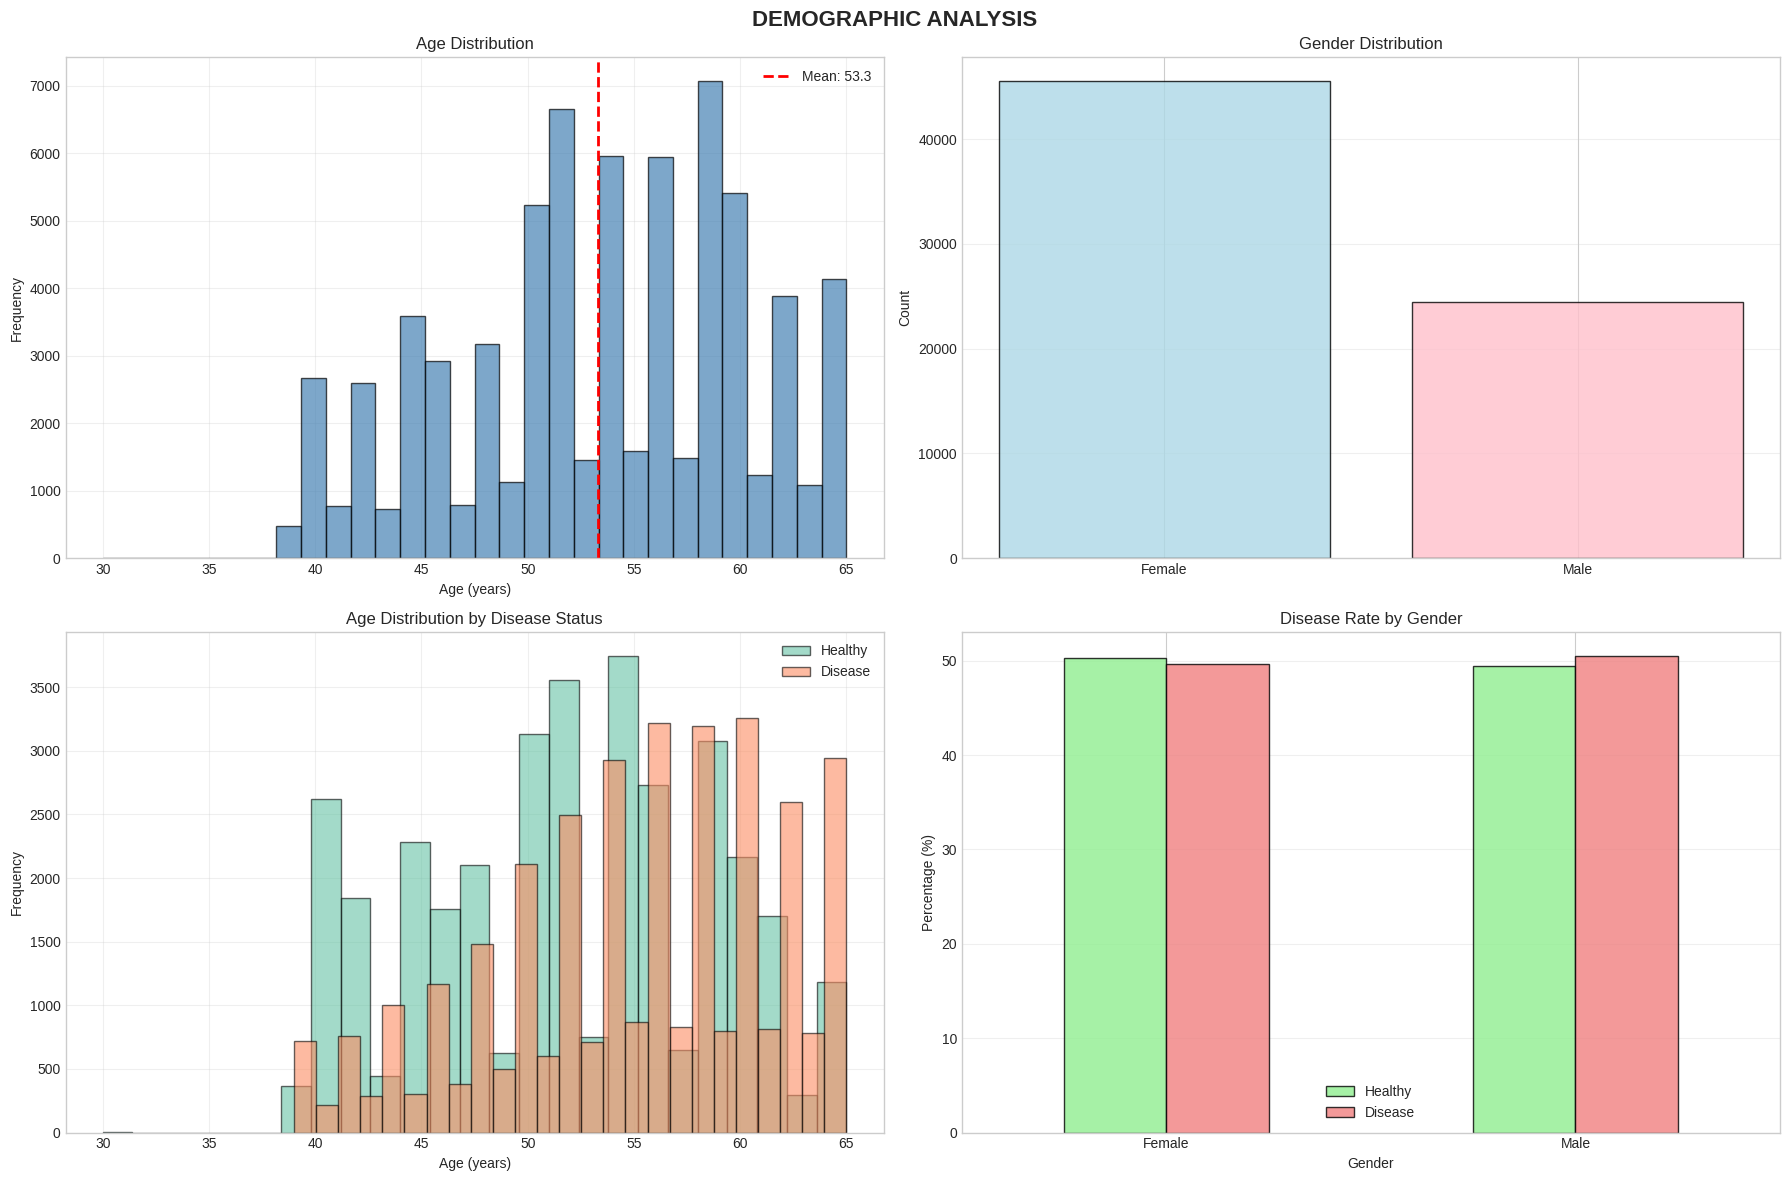

In [10]:
# Age conversion (days to years)
age_cols = [col for col in df.columns if 'age' in col.lower()]
if age_cols:
    age_col = age_cols[0]
    # Convert days to years
    df['age_years'] = (df[age_col] / 365.25).round(0)

    print(f'AGE STATISTICS (years):')
    print(f'  Mean: {df["age_years"].mean():.1f}')
    print(f'  Median: {df["age_years"].median():.1f}')
    print(f'  Min: {df["age_years"].min():.0f}')
    print(f'  Max: {df["age_years"].max():.0f}')

# Gender analysis
gender_cols = [col for col in df.columns if 'gender' in col.lower()]
if gender_cols:
    gender_col = gender_cols[0]
    print(f'\nGENDER DISTRIBUTION:')
    print(df[gender_col].value_counts())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('DEMOGRAPHIC ANALYSIS', fontsize=16, fontweight='bold')

# Age distribution
if 'age_years' in df.columns:
    axes[0, 0].hist(df['age_years'], bins=30, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['age_years'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f'Mean: {df["age_years"].mean():.1f}')
    axes[0, 0].set_xlabel('Age (years)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Age Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

# Gender distribution
if gender_cols:
    gender_counts = df[gender_col].value_counts()
    axes[0, 1].bar(range(len(gender_counts)), gender_counts.values,
                  color=['lightblue', 'pink'], edgecolor='black', alpha=0.8)
    axes[0, 1].set_xticks(range(len(gender_counts)))
    axes[0, 1].set_xticklabels(['Female', 'Male'])
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Gender Distribution')
    axes[0, 1].grid(axis='y', alpha=0.3)

# Age by disease status
if 'age_years' in df.columns:
    for status in sorted(df[target_col].unique()):
        subset = df[df[target_col] == status]['age_years']
        label = 'Disease' if status == 1 else 'Healthy'
        axes[1, 0].hist(subset, bins=25, alpha=0.6, label=label, edgecolor='black')
    axes[1, 0].set_xlabel('Age (years)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Age Distribution by Disease Status')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

# Gender vs disease
if gender_cols:
    ct = pd.crosstab(df[gender_col], df[target_col], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[1, 1], stacked=False,
           color=['lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')
    axes[1, 1].set_xticklabels(['Female', 'Male'], rotation=0)
    axes[1, 1].set_xlabel('Gender')
    axes[1, 1].set_ylabel('Percentage (%)')
    axes[1, 1].set_title('Disease Rate by Gender')
    axes[1, 1].legend(['Healthy', 'Disease'])
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Blood Pressure Analysis - CRITICAL RISK FACTOR

BLOOD PRESSURE STATISTICS:

Systolic (ap_hi):
  Mean: 128.8 mmHg
  Median: 120.0 mmHg
  Range: -150 - 16020 mmHg

Diastolic (ap_lo):
  Mean: 96.6 mmHg
  Median: 80.0 mmHg
  Range: -70 - 11000 mmHg


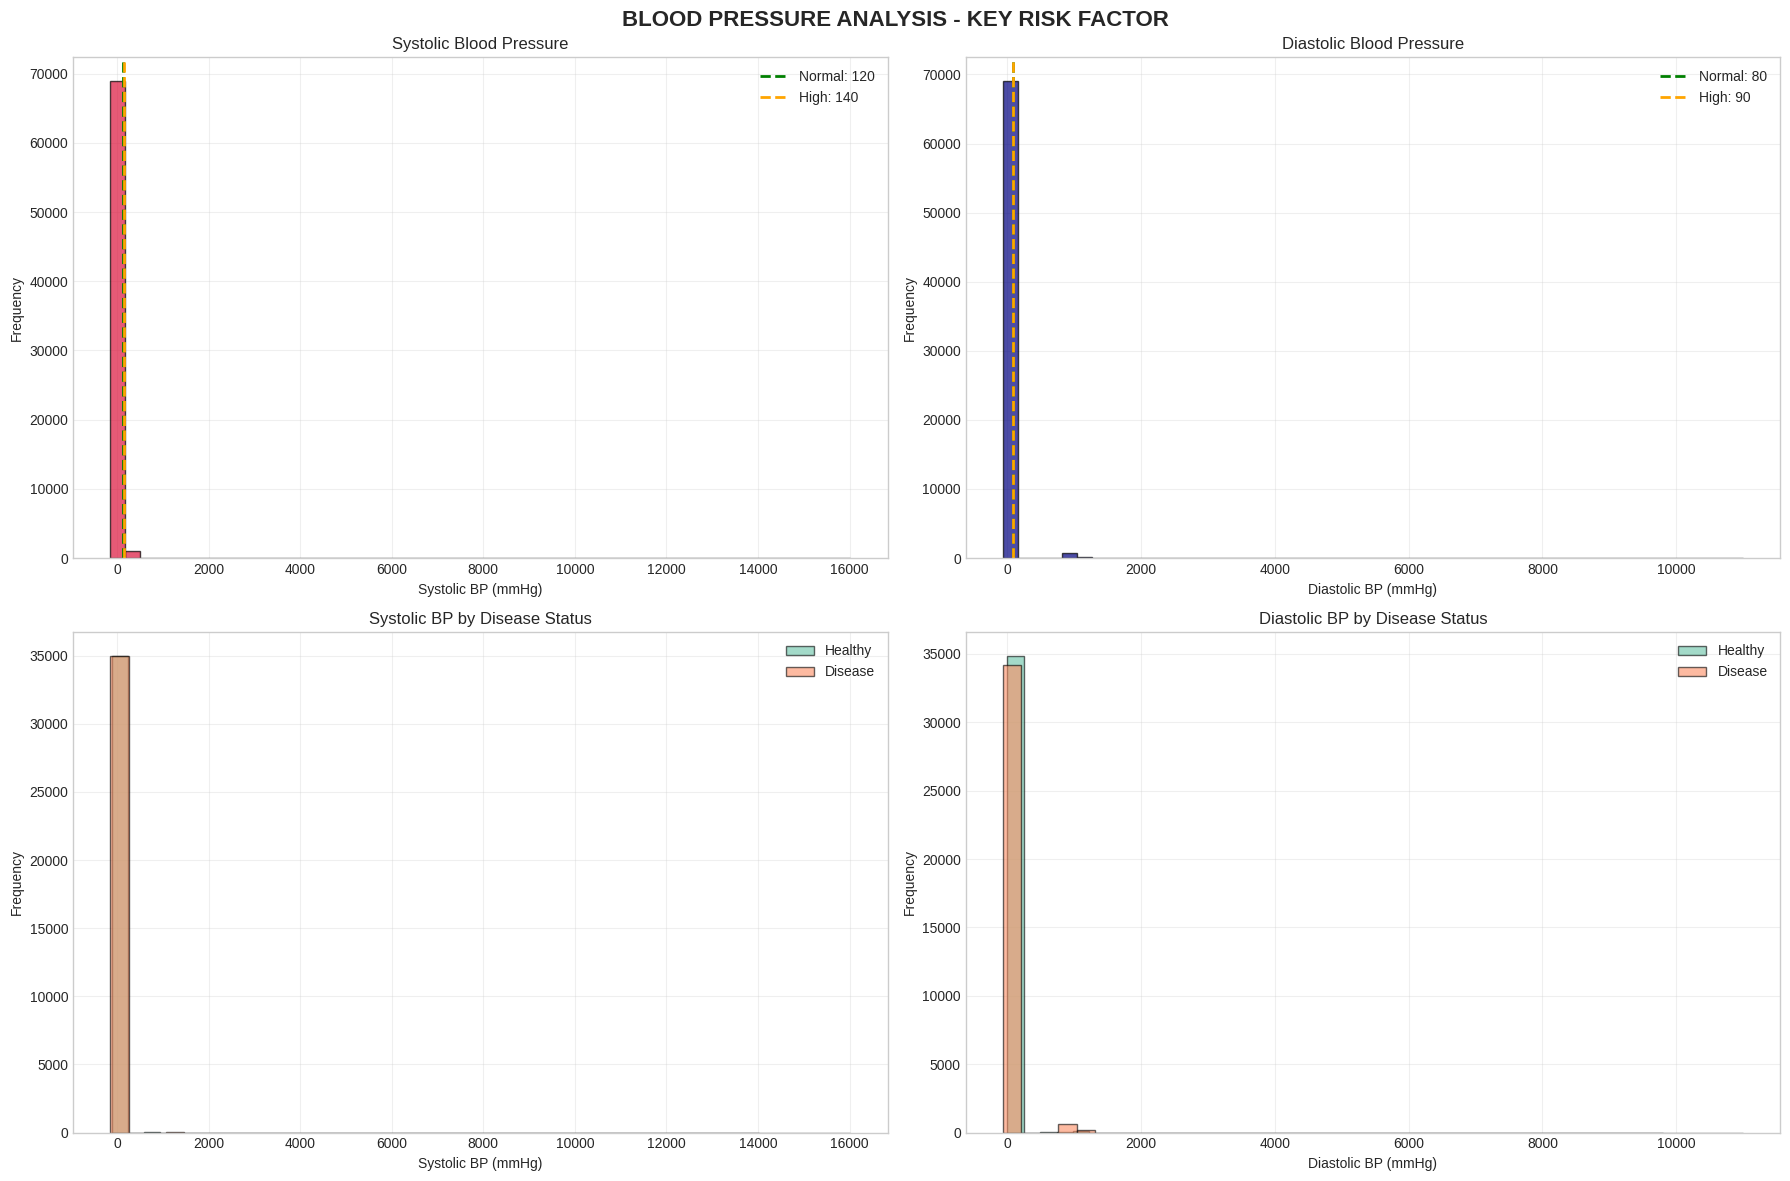

In [11]:
# Blood pressure columns
ap_sys_cols = [col for col in df.columns if 'ap_hi' in col.lower() or 'systolic' in col.lower()]
ap_dia_cols = [col for col in df.columns if 'ap_lo' in col.lower() or 'diastolic' in col.lower()]

if ap_sys_cols and ap_dia_cols:
    ap_sys = ap_sys_cols[0]
    ap_dia = ap_dia_cols[0]

    print('BLOOD PRESSURE STATISTICS:')
    print(f'\nSystolic (ap_hi):')
    print(f'  Mean: {df[ap_sys].mean():.1f} mmHg')
    print(f'  Median: {df[ap_sys].median():.1f} mmHg')
    print(f'  Range: {df[ap_sys].min():.0f} - {df[ap_sys].max():.0f} mmHg')

    print(f'\nDiastolic (ap_lo):')
    print(f'  Mean: {df[ap_dia].mean():.1f} mmHg')
    print(f'  Median: {df[ap_dia].median():.1f} mmHg')
    print(f'  Range: {df[ap_dia].min():.0f} - {df[ap_dia].max():.0f} mmHg')

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('BLOOD PRESSURE ANALYSIS - KEY RISK FACTOR', fontsize=16, fontweight='bold')

    # Systolic distribution
    axes[0, 0].hist(df[ap_sys], bins=50, color='crimson', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(120, color='green', linestyle='--', linewidth=2, label='Normal: 120')
    axes[0, 0].axvline(140, color='orange', linestyle='--', linewidth=2, label='High: 140')
    axes[0, 0].set_xlabel('Systolic BP (mmHg)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Systolic Blood Pressure')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Diastolic distribution
    axes[0, 1].hist(df[ap_dia], bins=50, color='navy', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(80, color='green', linestyle='--', linewidth=2, label='Normal: 80')
    axes[0, 1].axvline(90, color='orange', linestyle='--', linewidth=2, label='High: 90')
    axes[0, 1].set_xlabel('Diastolic BP (mmHg)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Diastolic Blood Pressure')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Systolic by disease
    for status in sorted(df[target_col].unique()):
        subset = df[df[target_col] == status][ap_sys]
        label = 'Disease' if status == 1 else 'Healthy'
        axes[1, 0].hist(subset, bins=40, alpha=0.6, label=label, edgecolor='black')
    axes[1, 0].set_xlabel('Systolic BP (mmHg)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Systolic BP by Disease Status')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Diastolic by disease
    for status in sorted(df[target_col].unique()):
        subset = df[df[target_col] == status][ap_dia]
        label = 'Disease' if status == 1 else 'Healthy'
        axes[1, 1].hist(subset, bins=40, alpha=0.6, label=label, edgecolor='black')
    axes[1, 1].set_xlabel('Diastolic BP (mmHg)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Diastolic BP by Disease Status')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### BMI & Physical Measurements

BMI STATISTICS:
  Mean: 27.56
  Median: 26.37
  Range: 3.47 - 298.67

BMI CATEGORIES:
bmi_category
Normal         25804
Overweight     25073
Obese          18444
Underweight      650
Name: count, dtype: int64


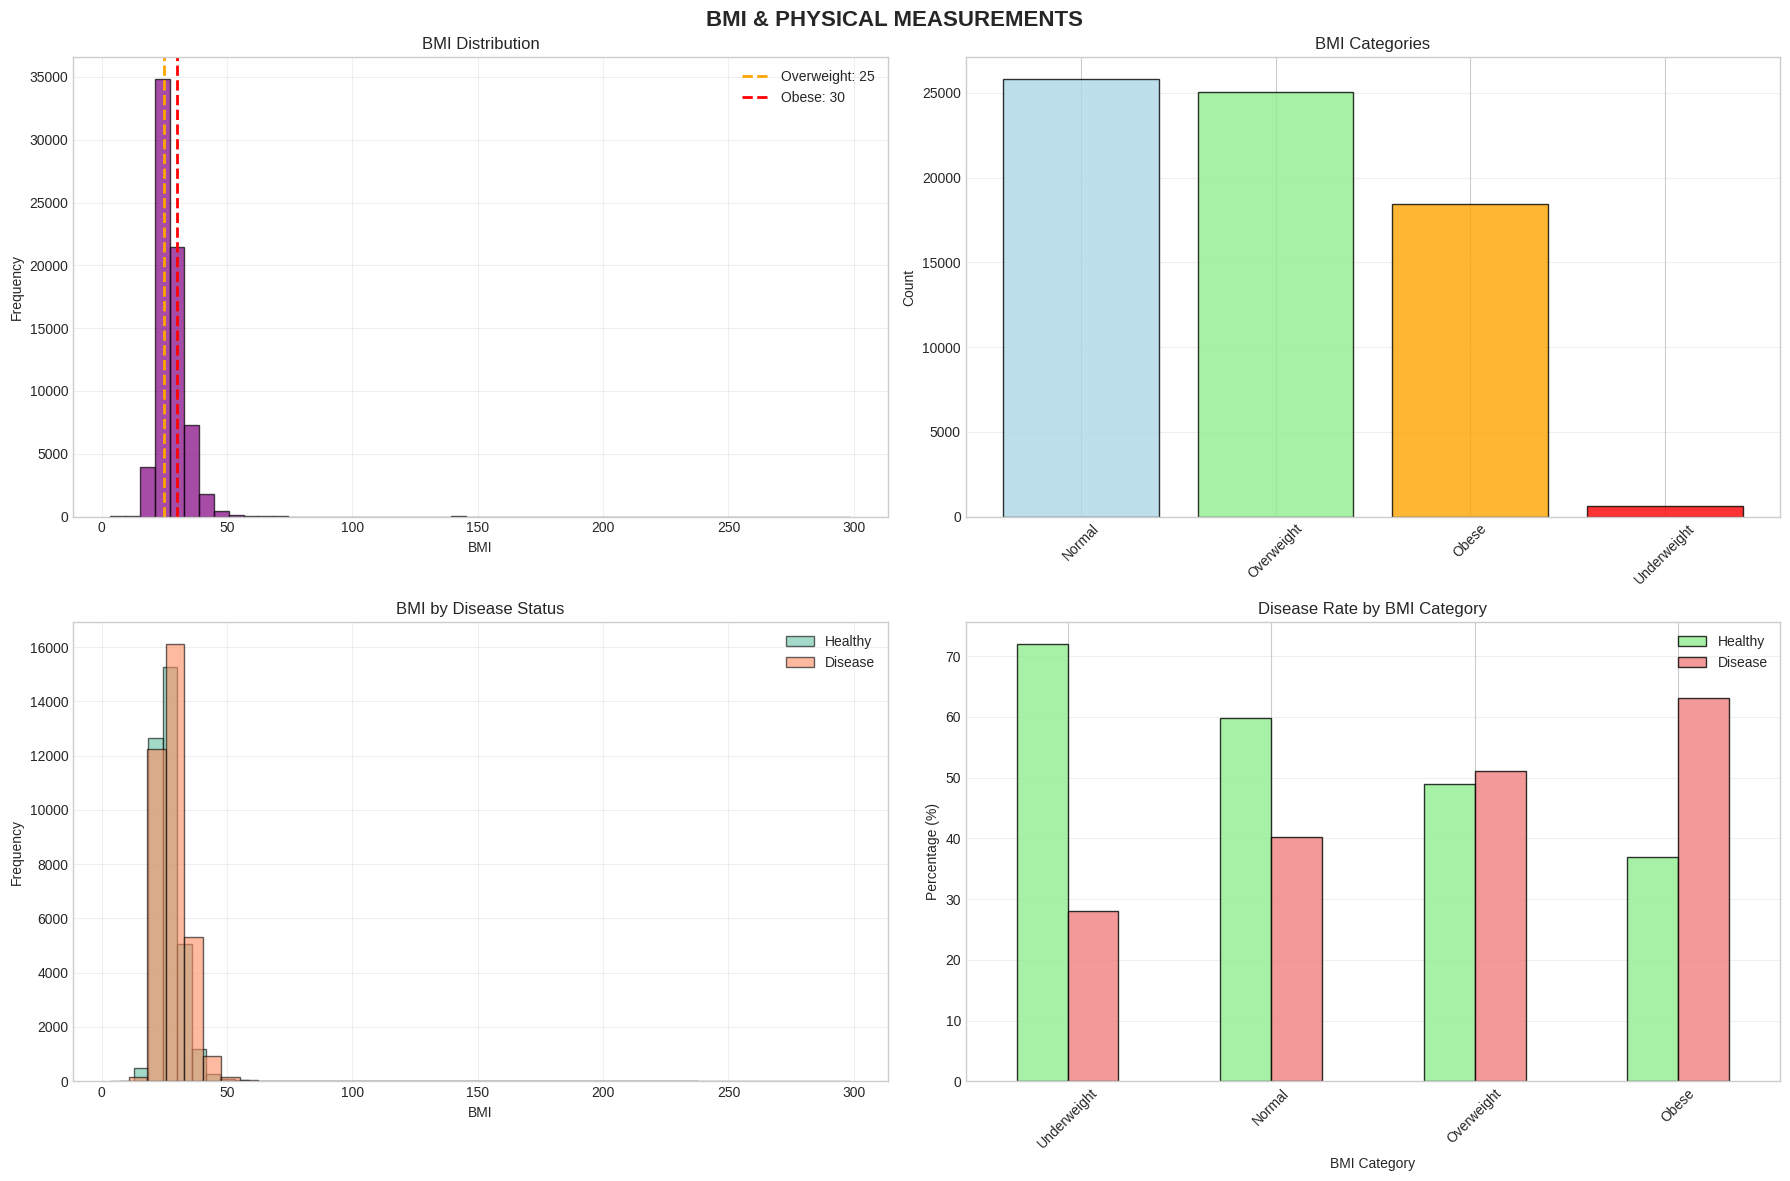

In [12]:
# Height and weight
height_cols = [col for col in df.columns if 'height' in col.lower()]
weight_cols = [col for col in df.columns if 'weight' in col.lower()]

if height_cols and weight_cols:
    height_col = height_cols[0]
    weight_col = weight_cols[0]

    # Calculate BMI
    df['bmi'] = df[weight_col] / ((df[height_col] / 100) ** 2)

    print('BMI STATISTICS:')
    print(f'  Mean: {df["bmi"].mean():.2f}')
    print(f'  Median: {df["bmi"].median():.2f}')
    print(f'  Range: {df["bmi"].min():.2f} - {df["bmi"].max():.2f}')

    # BMI categories
    df['bmi_category'] = pd.cut(df['bmi'],
                                bins=[0, 18.5, 25, 30, 100],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

    print('\nBMI CATEGORIES:')
    print(df['bmi_category'].value_counts())

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('BMI & PHYSICAL MEASUREMENTS', fontsize=16, fontweight='bold')

    # BMI distribution
    axes[0, 0].hist(df['bmi'], bins=50, color='purple', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(25, color='orange', linestyle='--', linewidth=2, label='Overweight: 25')
    axes[0, 0].axvline(30, color='red', linestyle='--', linewidth=2, label='Obese: 30')
    axes[0, 0].set_xlabel('BMI')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('BMI Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # BMI categories
    bmi_cat_counts = df['bmi_category'].value_counts()
    axes[0, 1].bar(range(len(bmi_cat_counts)), bmi_cat_counts.values,
                  color=['lightblue', 'lightgreen', 'orange', 'red'],
                  edgecolor='black', alpha=0.8)
    axes[0, 1].set_xticks(range(len(bmi_cat_counts)))
    axes[0, 1].set_xticklabels(bmi_cat_counts.index, rotation=45)
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('BMI Categories')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # BMI by disease
    for status in sorted(df[target_col].unique()):
        subset = df[df[target_col] == status]['bmi']
        label = 'Disease' if status == 1 else 'Healthy'
        axes[1, 0].hist(subset, bins=40, alpha=0.6, label=label, edgecolor='black')
    axes[1, 0].set_xlabel('BMI')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('BMI by Disease Status')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Disease rate by BMI category
    ct = pd.crosstab(df['bmi_category'], df[target_col], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[1, 1], stacked=False,
           color=['lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')
    axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)
    axes[1, 1].set_xlabel('BMI Category')
    axes[1, 1].set_ylabel('Percentage (%)')
    axes[1, 1].set_title('Disease Rate by BMI Category')
    axes[1, 1].legend(['Healthy', 'Disease'])
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

### Cholesterol & Glucose - Metabolic Factors

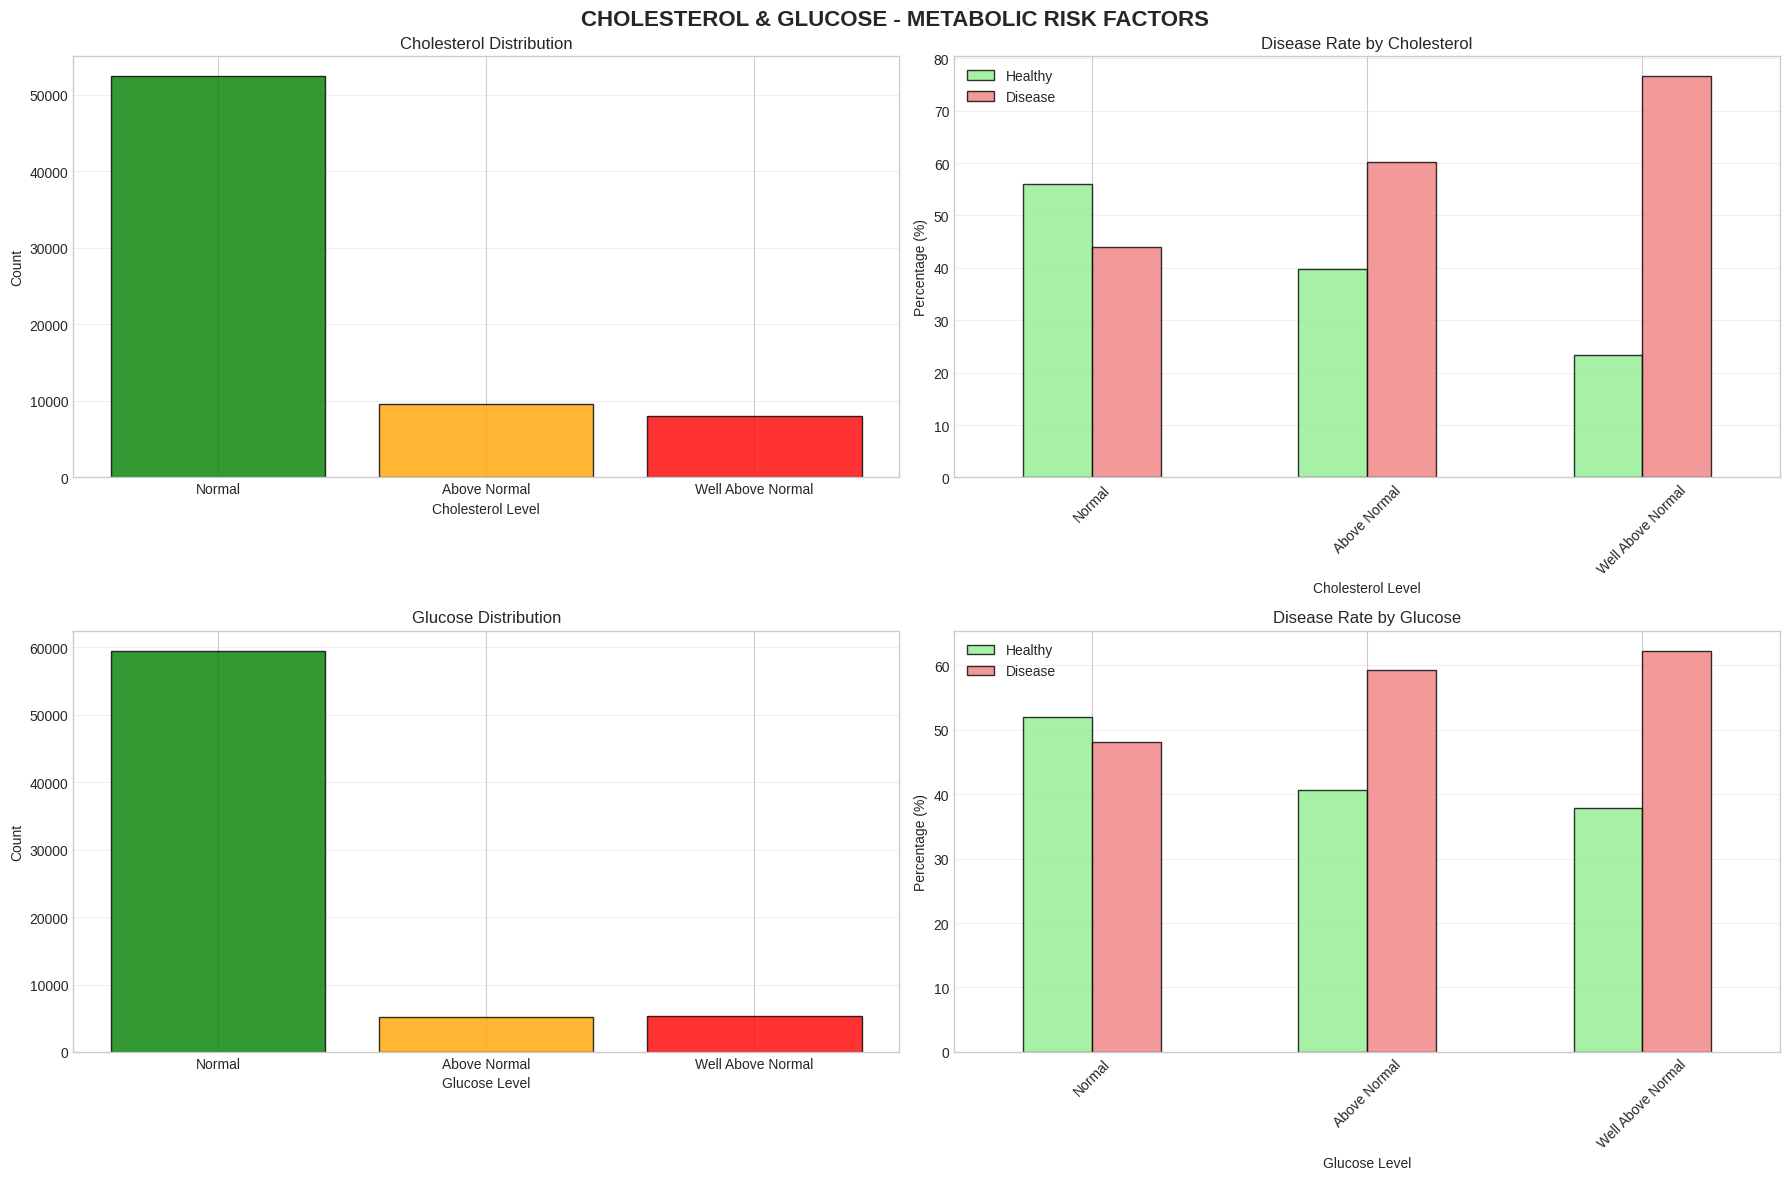

In [13]:
# Cholesterol and glucose
chol_cols = [col for col in df.columns if 'chol' in col.lower()]
gluc_cols = [col for col in df.columns if 'gluc' in col.lower()]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('CHOLESTEROL & GLUCOSE - METABOLIC RISK FACTORS', fontsize=16, fontweight='bold')

if chol_cols:
    chol_col = chol_cols[0]

    # Cholesterol distribution
    chol_counts = df[chol_col].value_counts().sort_index()
    axes[0, 0].bar(chol_counts.index, chol_counts.values,
                  color=['green', 'orange', 'red'], edgecolor='black', alpha=0.8)
    axes[0, 0].set_xlabel('Cholesterol Level')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Cholesterol Distribution')
    axes[0, 0].set_xticks(chol_counts.index)
    axes[0, 0].set_xticklabels(['Normal', 'Above Normal', 'Well Above Normal'])
    axes[0, 0].grid(axis='y', alpha=0.3)

    # Cholesterol vs disease
    ct = pd.crosstab(df[chol_col], df[target_col], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[0, 1], stacked=False,
           color=['lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')
    axes[0, 1].set_xticklabels(['Normal', 'Above Normal', 'Well Above Normal'], rotation=45)
    axes[0, 1].set_xlabel('Cholesterol Level')
    axes[0, 1].set_ylabel('Percentage (%)')
    axes[0, 1].set_title('Disease Rate by Cholesterol')
    axes[0, 1].legend(['Healthy', 'Disease'])
    axes[0, 1].grid(axis='y', alpha=0.3)

if gluc_cols:
    gluc_col = gluc_cols[0]

    # Glucose distribution
    gluc_counts = df[gluc_col].value_counts().sort_index()
    axes[1, 0].bar(gluc_counts.index, gluc_counts.values,
                  color=['green', 'orange', 'red'], edgecolor='black', alpha=0.8)
    axes[1, 0].set_xlabel('Glucose Level')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Glucose Distribution')
    axes[1, 0].set_xticks(gluc_counts.index)
    axes[1, 0].set_xticklabels(['Normal', 'Above Normal', 'Well Above Normal'])
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Glucose vs disease
    ct = pd.crosstab(df[gluc_col], df[target_col], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[1, 1], stacked=False,
           color=['lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')
    axes[1, 1].set_xticklabels(['Normal', 'Above Normal', 'Well Above Normal'], rotation=45)
    axes[1, 1].set_xlabel('Glucose Level')
    axes[1, 1].set_ylabel('Percentage (%)')
    axes[1, 1].set_title('Disease Rate by Glucose')
    axes[1, 1].legend(['Healthy', 'Disease'])
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Lifestyle Factors - Smoking, Alcohol, Activity

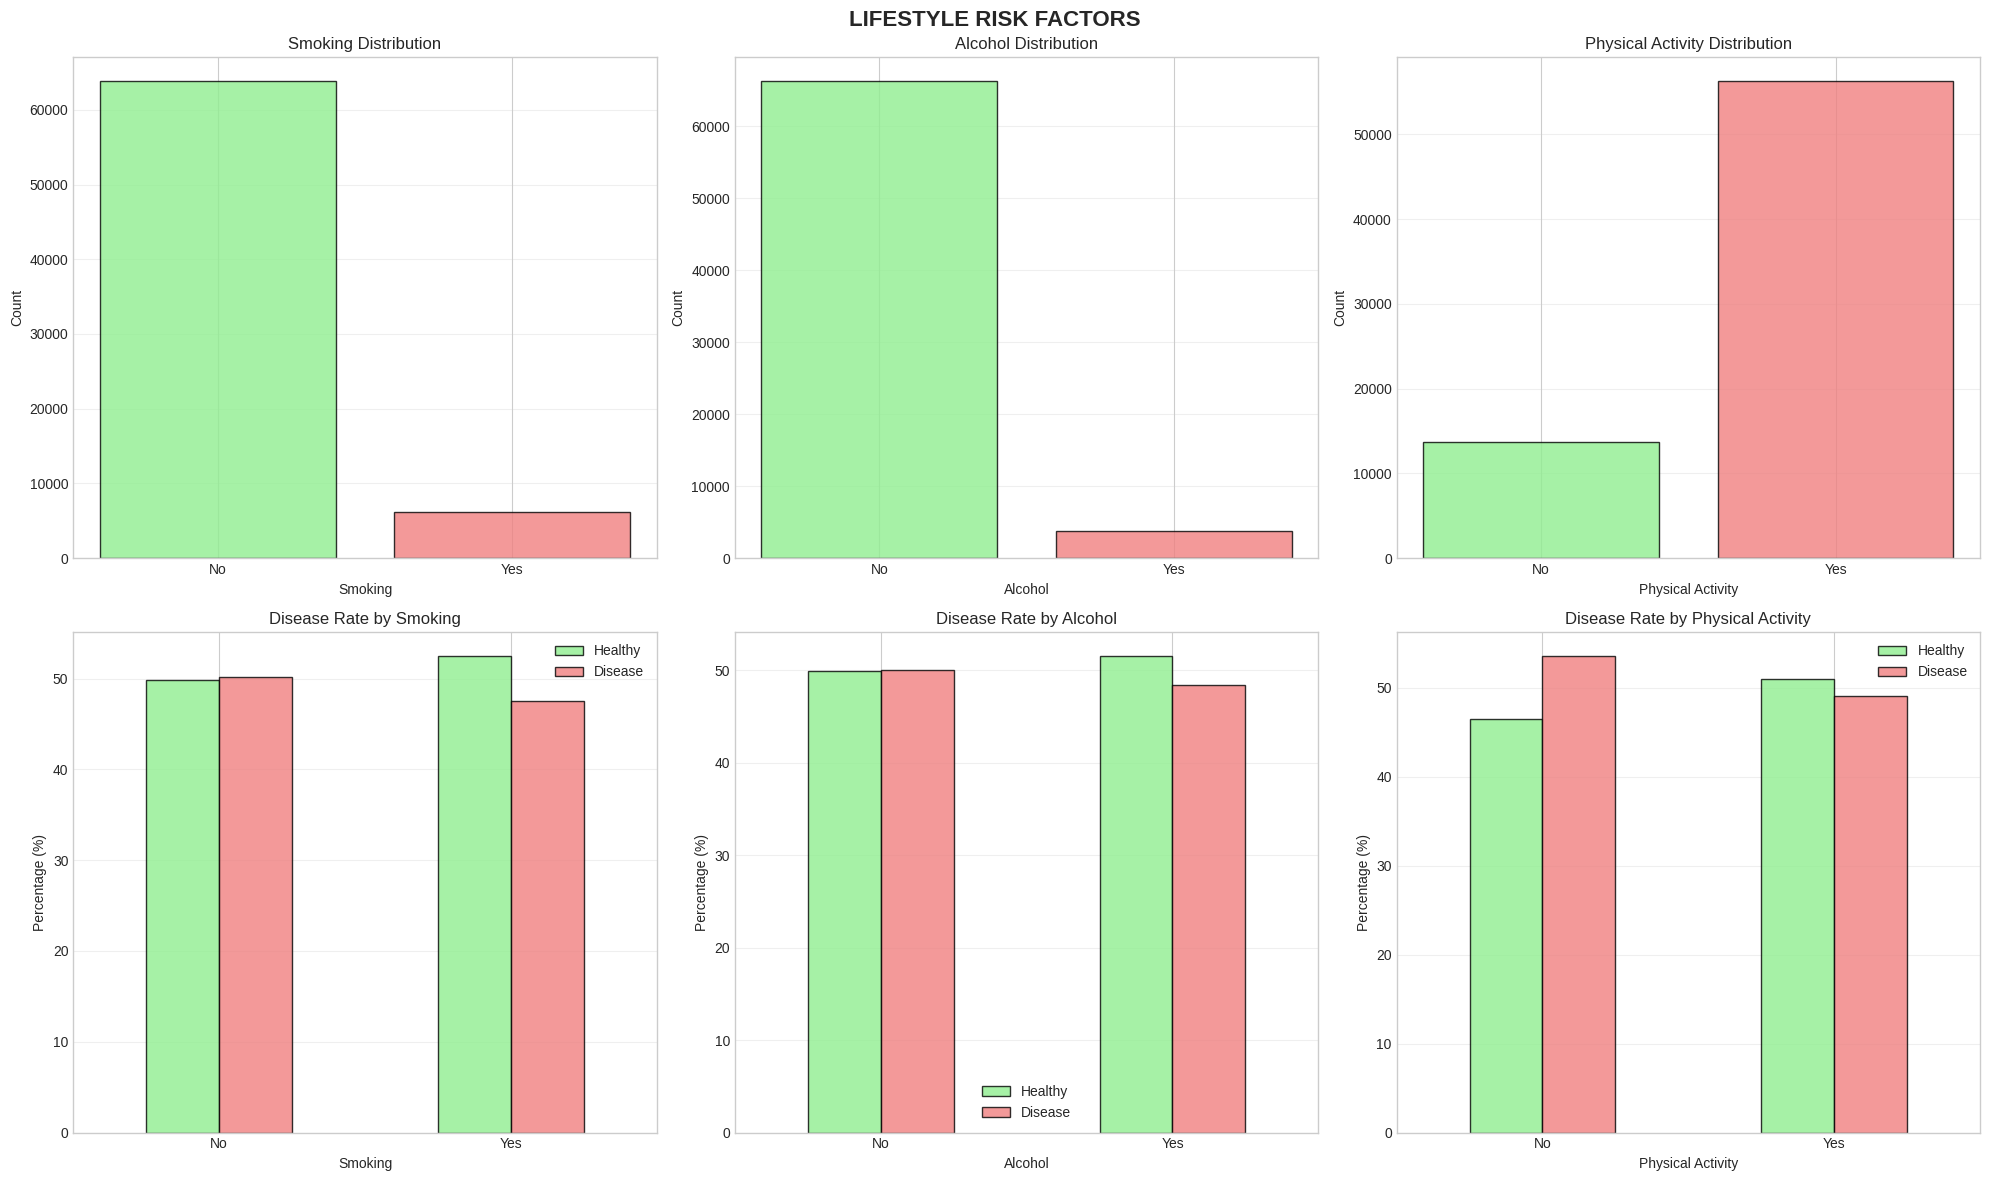

In [14]:
# Lifestyle columns
smoke_cols = [col for col in df.columns if 'smoke' in col.lower()]
alco_cols = [col for col in df.columns if 'alco' in col.lower()]
active_cols = [col for col in df.columns if 'active' in col.lower()]

lifestyle_cols = []
if smoke_cols:
    lifestyle_cols.append(smoke_cols[0])
if alco_cols:
    lifestyle_cols.append(alco_cols[0])
if active_cols:
    lifestyle_cols.append(active_cols[0])

if len(lifestyle_cols) >= 3:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('LIFESTYLE RISK FACTORS', fontsize=16, fontweight='bold')

    titles = ['Smoking', 'Alcohol', 'Physical Activity']

    for idx, (col, title) in enumerate(zip(lifestyle_cols, titles)):
        # Distribution
        counts = df[col].value_counts().sort_index()
        axes[0, idx].bar(counts.index, counts.values,
                        color=['lightgreen', 'lightcoral'], edgecolor='black', alpha=0.8)
        axes[0, idx].set_xlabel(title)
        axes[0, idx].set_ylabel('Count')
        axes[0, idx].set_title(f'{title} Distribution')
        axes[0, idx].set_xticks([0, 1])
        axes[0, idx].set_xticklabels(['No', 'Yes'])
        axes[0, idx].grid(axis='y', alpha=0.3)

        # vs Disease
        ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
        ct.plot(kind='bar', ax=axes[1, idx], stacked=False,
               color=['lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')
        axes[1, idx].set_xticklabels(['No', 'Yes'], rotation=0)
        axes[1, idx].set_xlabel(title)
        axes[1, idx].set_ylabel('Percentage (%)')
        axes[1, idx].set_title(f'Disease Rate by {title}')
        axes[1, idx].legend(['Healthy', 'Disease'])
        axes[1, idx].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

### Correlation Analysis

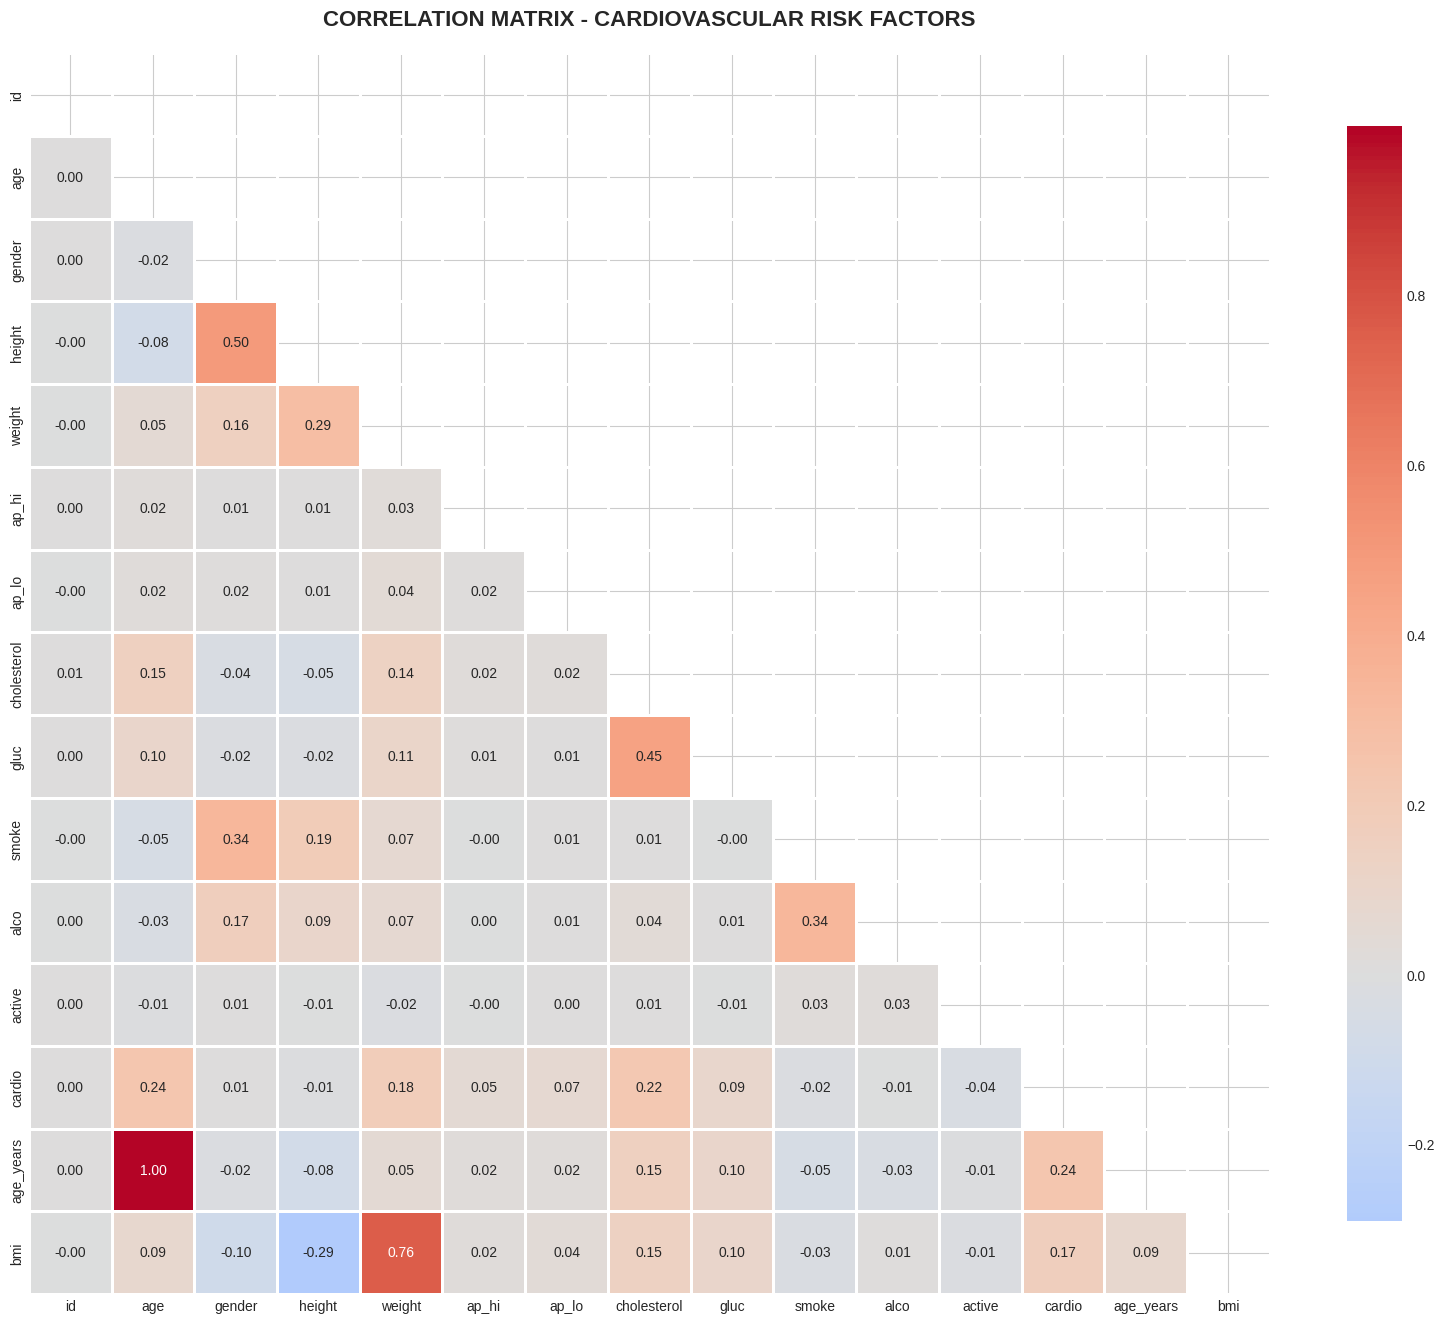

CARDIOVASCULAR DISEASE CORRELATIONS:
cardio        1.0000
age           0.2382
age_years     0.2378
cholesterol   0.2211
weight        0.1817
bmi           0.1656
gluc          0.0893
ap_lo         0.0657
ap_hi         0.0545
active        0.0357
smoke         0.0155
height        0.0108
gender        0.0081
alco          0.0073
id            0.0038
Name: cardio, dtype: float64


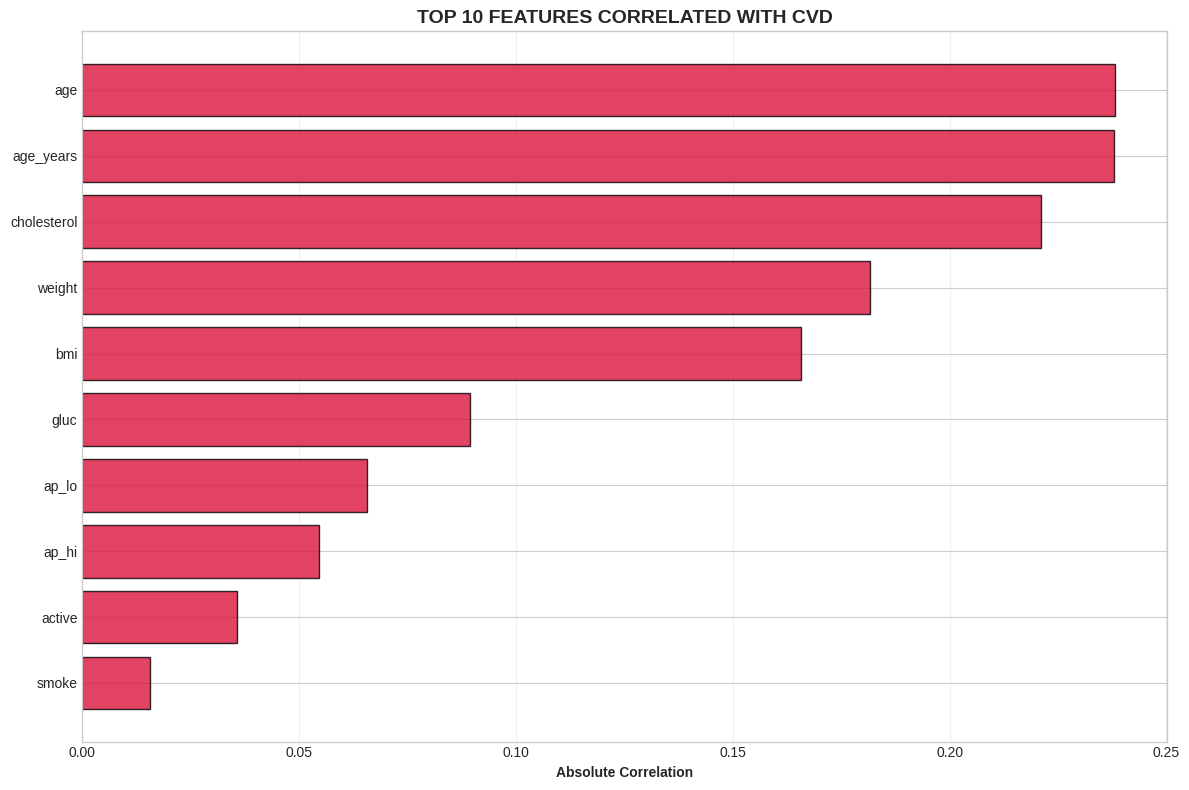

In [15]:
# Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
           cmap='coolwarm', center=0, linewidths=1,
           cbar_kws={'shrink': 0.8}, square=True)
plt.title('CORRELATION MATRIX - CARDIOVASCULAR RISK FACTORS', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Target correlation
if target_col in corr.columns:
    target_corr = corr[target_col].abs().sort_values(ascending=False)
    print('CARDIOVASCULAR DISEASE CORRELATIONS:')
    print('='*80)
    print(target_corr)

    # Visual
    plt.figure(figsize=(12, 8))
    top_corr = target_corr[target_corr.index != target_col].head(10)
    plt.barh(range(len(top_corr)), top_corr.values,
            color='crimson', edgecolor='black', alpha=0.8)
    plt.yticks(range(len(top_corr)), top_corr.index)
    plt.xlabel('Absolute Correlation', fontweight='bold')
    plt.title('TOP 10 FEATURES CORRELATED WITH CVD', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. DATA CLEANING & FEATURE ENGINEERING

In [16]:
print('='*80)
print('DATA CLEANING')
print('='*80)

df_clean = df.copy()

# Remove outliers in blood pressure
if ap_sys_cols and ap_dia_cols:
    # Remove impossible values
    df_clean = df_clean[(df_clean[ap_sys] > 70) & (df_clean[ap_sys] < 250)]
    df_clean = df_clean[(df_clean[ap_dia] > 40) & (df_clean[ap_dia] < 150)]
    df_clean = df_clean[df_clean[ap_sys] > df_clean[ap_dia]]  # Systolic > Diastolic
    print(f'Blood pressure outliers removed')

# Remove outliers in height/weight
if height_cols and weight_cols:
    df_clean = df_clean[(df_clean[height_col] > 130) & (df_clean[height_col] < 220)]
    df_clean = df_clean[(df_clean[weight_col] > 30) & (df_clean[weight_col] < 200)]
    print(f'Height/weight outliers removed')

# Duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicates removed')

print(f'\nClean data: {len(df_clean):,} records')
print(f'Removed: {len(df) - len(df_clean):,} records ({(len(df) - len(df_clean))/len(df)*100:.2f}%)')
print('='*80)

DATA CLEANING
Blood pressure outliers removed
Height/weight outliers removed

Clean data: 68,537 records
Removed: 1,463 records (2.09%)


In [17]:
print('='*80)
print('CLINICAL FEATURE ENGINEERING')
print('='*80)

# Recalculate BMI if needed
if height_cols and weight_cols and 'bmi' not in df_clean.columns:
    df_clean['bmi'] = df_clean[weight_col] / ((df_clean[height_col] / 100) ** 2)
    print('BMI calculated')

# Blood pressure categories
if ap_sys_cols:
    df_clean['bp_category'] = pd.cut(df_clean[ap_sys],
                                     bins=[0, 120, 140, 180, 300],
                                     labels=['Normal', 'Elevated', 'High', 'Very High'])
    print('BP categories created')

# Age groups
if 'age_years' in df_clean.columns:
    df_clean['age_group'] = pd.cut(df_clean['age_years'],
                                   bins=[0, 40, 50, 60, 100],
                                   labels=['Young', 'Middle', 'Senior', 'Elderly'])
    print('Age groups created')

# Risk score (simple)
if ap_sys_cols and 'bmi' in df_clean.columns and chol_cols and gluc_cols:
    df_clean['risk_score'] = 0
    df_clean['risk_score'] += (df_clean[ap_sys] > 140).astype(int)  # High BP
    df_clean['risk_score'] += (df_clean['bmi'] > 30).astype(int)  # Obese
    df_clean['risk_score'] += (df_clean[chol_col] > 1).astype(int)  # High cholesterol
    df_clean['risk_score'] += (df_clean[gluc_col] > 1).astype(int)  # High glucose
    if smoke_cols:
        df_clean['risk_score'] += df_clean[smoke_cols[0]]  # Smoking
    print('Risk score created (0-5)')

# Pulse pressure
if ap_sys_cols and ap_dia_cols:
    df_clean['pulse_pressure'] = df_clean[ap_sys] - df_clean[ap_dia]
    print('Pulse pressure created')

# MAP (Mean Arterial Pressure)
if ap_sys_cols and ap_dia_cols:
    df_clean['map'] = (df_clean[ap_sys] + 2 * df_clean[ap_dia]) / 3
    print('MAP created')

print(f'\nFinal columns: {len(df_clean.columns)}')
print('='*80)

CLINICAL FEATURE ENGINEERING
BP categories created
Age groups created
Risk score created (0-5)
Pulse pressure created
MAP created

Final columns: 21


## 5. MODEL PREPARATION - TARGET ENCODING!

In [18]:
print('='*80)
print('MODEL PREPARATION - TARGET ENCODING')
print('='*80)

# Target encoding
print(f'\nTarget column: {target_col}')
print(f'Original values: {df_clean[target_col].unique()}')
print(f'Data type: {df_clean[target_col].dtype}')

if df_clean[target_col].dtype == 'object':
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(df_clean[target_col])
    print(f'\nEncoded with LabelEncoder')
    print(f'Mapping: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}')
else:
    y = df_clean[target_col].values
    print(f'\nAlready numeric, using as-is')

print(f'Final target values: {np.unique(y)}')
print(f'Target dtype: {y.dtype}')

# Features
X = df_clean.drop(columns=[target_col]).copy()

# Drop ID columns
id_cols = [col for col in X.columns if 'id' in col.lower()]
if id_cols:
    X = X.drop(columns=id_cols)
    print(f'\nDropped ID columns: {id_cols}')

# Encode categorical
print(f'\nEncoding features...')
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'  Binary: {col}')
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)
        print(f'  One-hot: {col}')

print(f'\n{"="*80}')
print('PREPARATION COMPLETE')
print(f'Features: {X.shape[1]}')
print(f'Samples: {len(X):,}')
print(f'Target type: {y.dtype}')
print('='*80)

MODEL PREPARATION - TARGET ENCODING

Target column: cardio
Original values: [0 1]
Data type: int64

Already numeric, using as-is
Final target values: [0 1]
Target dtype: int64

Dropped ID columns: ['id']

Encoding features...
  One-hot: bmi_category
  One-hot: bp_category
  One-hot: age_group

PREPARATION COMPLETE
Features: 25
Samples: 68,537
Target type: int64


In [19]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split:')
print(f'  Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Test: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\nScaling: DONE (StandardScaler)')

# SMOTE
print('\nSMOTE...')
print(f'Before: {dict(zip(*np.unique(y_train, return_counts=True)))}')
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'After: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}')
print(f'SMOTE: {len(X_train):,} -> {len(X_train_smote):,}')

Train-Test Split:
  Train: 54,829 (80.0%)
  Test: 13,708 (20.0%)

Scaling: DONE (StandardScaler)

SMOTE...
Before: {np.int64(0): np.int64(27705), np.int64(1): np.int64(27124)}
After: {np.int64(0): np.int64(27705), np.int64(1): np.int64(27705)}
SMOTE: 54,829 -> 55,410


## 6. ML MODELS - 15 MODELS

In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis()
}

print(f'{len(models)} MODELS DEFINED')
for name in models.keys():
    print(f'  - {name}')

15 MODELS DEFINED
  - Logistic Regression
  - Ridge Classifier
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - SVM (RBF)
  - SVM (Linear)
  - KNN
  - Naive Bayes
  - AdaBoost
  - Extra Trees
  - LDA


In [21]:
results = {}

print('='*80)
print('MODEL TRAINING - CARDIOVASCULAR DISEASE PREDICTION')
print('='*80)

for name, model in models.items():
    print(f'\n{name}...')

    try:
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        # Medical metrics
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall for positive class
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precision for positive class
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0

        roc_auc = None
        if y_pred_proba is not None and len(np.unique(y_test)) == 2:
            roc_auc = roc_auc_score(y_test, y_pred_proba)

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'PPV': ppv,
            'NPV': npv,
            'ROC_AUC': roc_auc,
            'predictions': y_pred,
            'pred_proba': y_pred_proba,
            'confusion_matrix': cm
        }

        print(f'  SUCCESS! Acc: {accuracy:.4f}, F1: {f1:.4f}, Sens: {sensitivity:.4f}')

    except Exception as e:
        print(f'  ERROR: {str(e)}')
        continue

print('\n' + '='*80)
print(f'TRAINING COMPLETE! {len(results)}/{len(models)} models successful')
print('='*80)

MODEL TRAINING - CARDIOVASCULAR DISEASE PREDICTION

Logistic Regression...
  SUCCESS! Acc: 0.7283, F1: 0.7275, Sens: 0.6776

Ridge Classifier...
  SUCCESS! Acc: 0.7275, F1: 0.7262, Sens: 0.6616

Decision Tree...
  SUCCESS! Acc: 0.7231, F1: 0.7228, Sens: 0.6950

Random Forest...
  SUCCESS! Acc: 0.7308, F1: 0.7303, Sens: 0.6877

Gradient Boosting...
  SUCCESS! Acc: 0.7342, F1: 0.7337, Sens: 0.6925

XGBoost...
  SUCCESS! Acc: 0.7281, F1: 0.7276, Sens: 0.6877

LightGBM...
  SUCCESS! Acc: 0.7337, F1: 0.7332, Sens: 0.6921

CatBoost...
  SUCCESS! Acc: 0.7279, F1: 0.7274, Sens: 0.6856

SVM (RBF)...
  SUCCESS! Acc: 0.7291, F1: 0.7289, Sens: 0.7065

SVM (Linear)...
  SUCCESS! Acc: 0.7105, F1: 0.7079, Sens: 0.6181

KNN...
  SUCCESS! Acc: 0.6899, F1: 0.6899, Sens: 0.6818

Naive Bayes...
  SUCCESS! Acc: 0.7105, F1: 0.7058, Sens: 0.5859

AdaBoost...
  SUCCESS! Acc: 0.7280, F1: 0.7264, Sens: 0.6530

Extra Trees...
  SUCCESS! Acc: 0.7338, F1: 0.7333, Sens: 0.6906

LDA...
  SUCCESS! Acc: 0.7275, F1: 0.

## 7. COMPREHENSIVE COMPARISON

### Results Table

In [22]:
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
        'Precision': [results[m]['Precision'] for m in results.keys()],
        'Recall': [results[m]['Recall'] for m in results.keys()],
        'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
        'Sensitivity': [results[m]['Sensitivity'] for m in results.keys()],
        'Specificity': [results[m]['Specificity'] for m in results.keys()],
        'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
    }).sort_values('F1 Score', ascending=False).reset_index(drop=True)

    print('='*120)
    print('CARDIOVASCULAR DISEASE PREDICTION - MODEL COMPARISON')
    print('='*120)
    print(results_df.to_string(index=False))
    print('='*120)

    best_model = results_df.iloc[0]['Model']
    print(f'\nBEST MODEL: {best_model}')
    print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
    print(f'  Sensitivity: {results_df.iloc[0]["Sensitivity"]:.4f}')
    print(f'  Specificity: {results_df.iloc[0]["Specificity"]:.4f}')
    print('='*120)
else:
    print('No models trained successfully!')

CARDIOVASCULAR DISEASE PREDICTION - MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score  Sensitivity  Specificity  ROC-AUC
  Gradient Boosting    0.7342     0.7353  0.7342    0.7337       0.6925       0.7749   0.7990
        Extra Trees    0.7338     0.7351  0.7338    0.7333       0.6906       0.7761   0.7960
           LightGBM    0.7337     0.7349  0.7337    0.7332       0.6921       0.7745   0.7987
      Random Forest    0.7308     0.7321  0.7308    0.7303       0.6877       0.7731   0.7949
          SVM (RBF)    0.7291     0.7293  0.7291    0.7289       0.7065       0.7511   0.7823
            XGBoost    0.7281     0.7292  0.7281    0.7276       0.6877       0.7677   0.7890
Logistic Regression    0.7283     0.7300  0.7283    0.7275       0.6776       0.7778   0.7906
           CatBoost    0.7279     0.7291  0.7279    0.7274       0.6856       0.7693   0.7920
           AdaBoost    0.7280     0.7323  0.7280    0.7264       0.6530       0.8014   0.7936
       

### Part 1: Basic Metrics

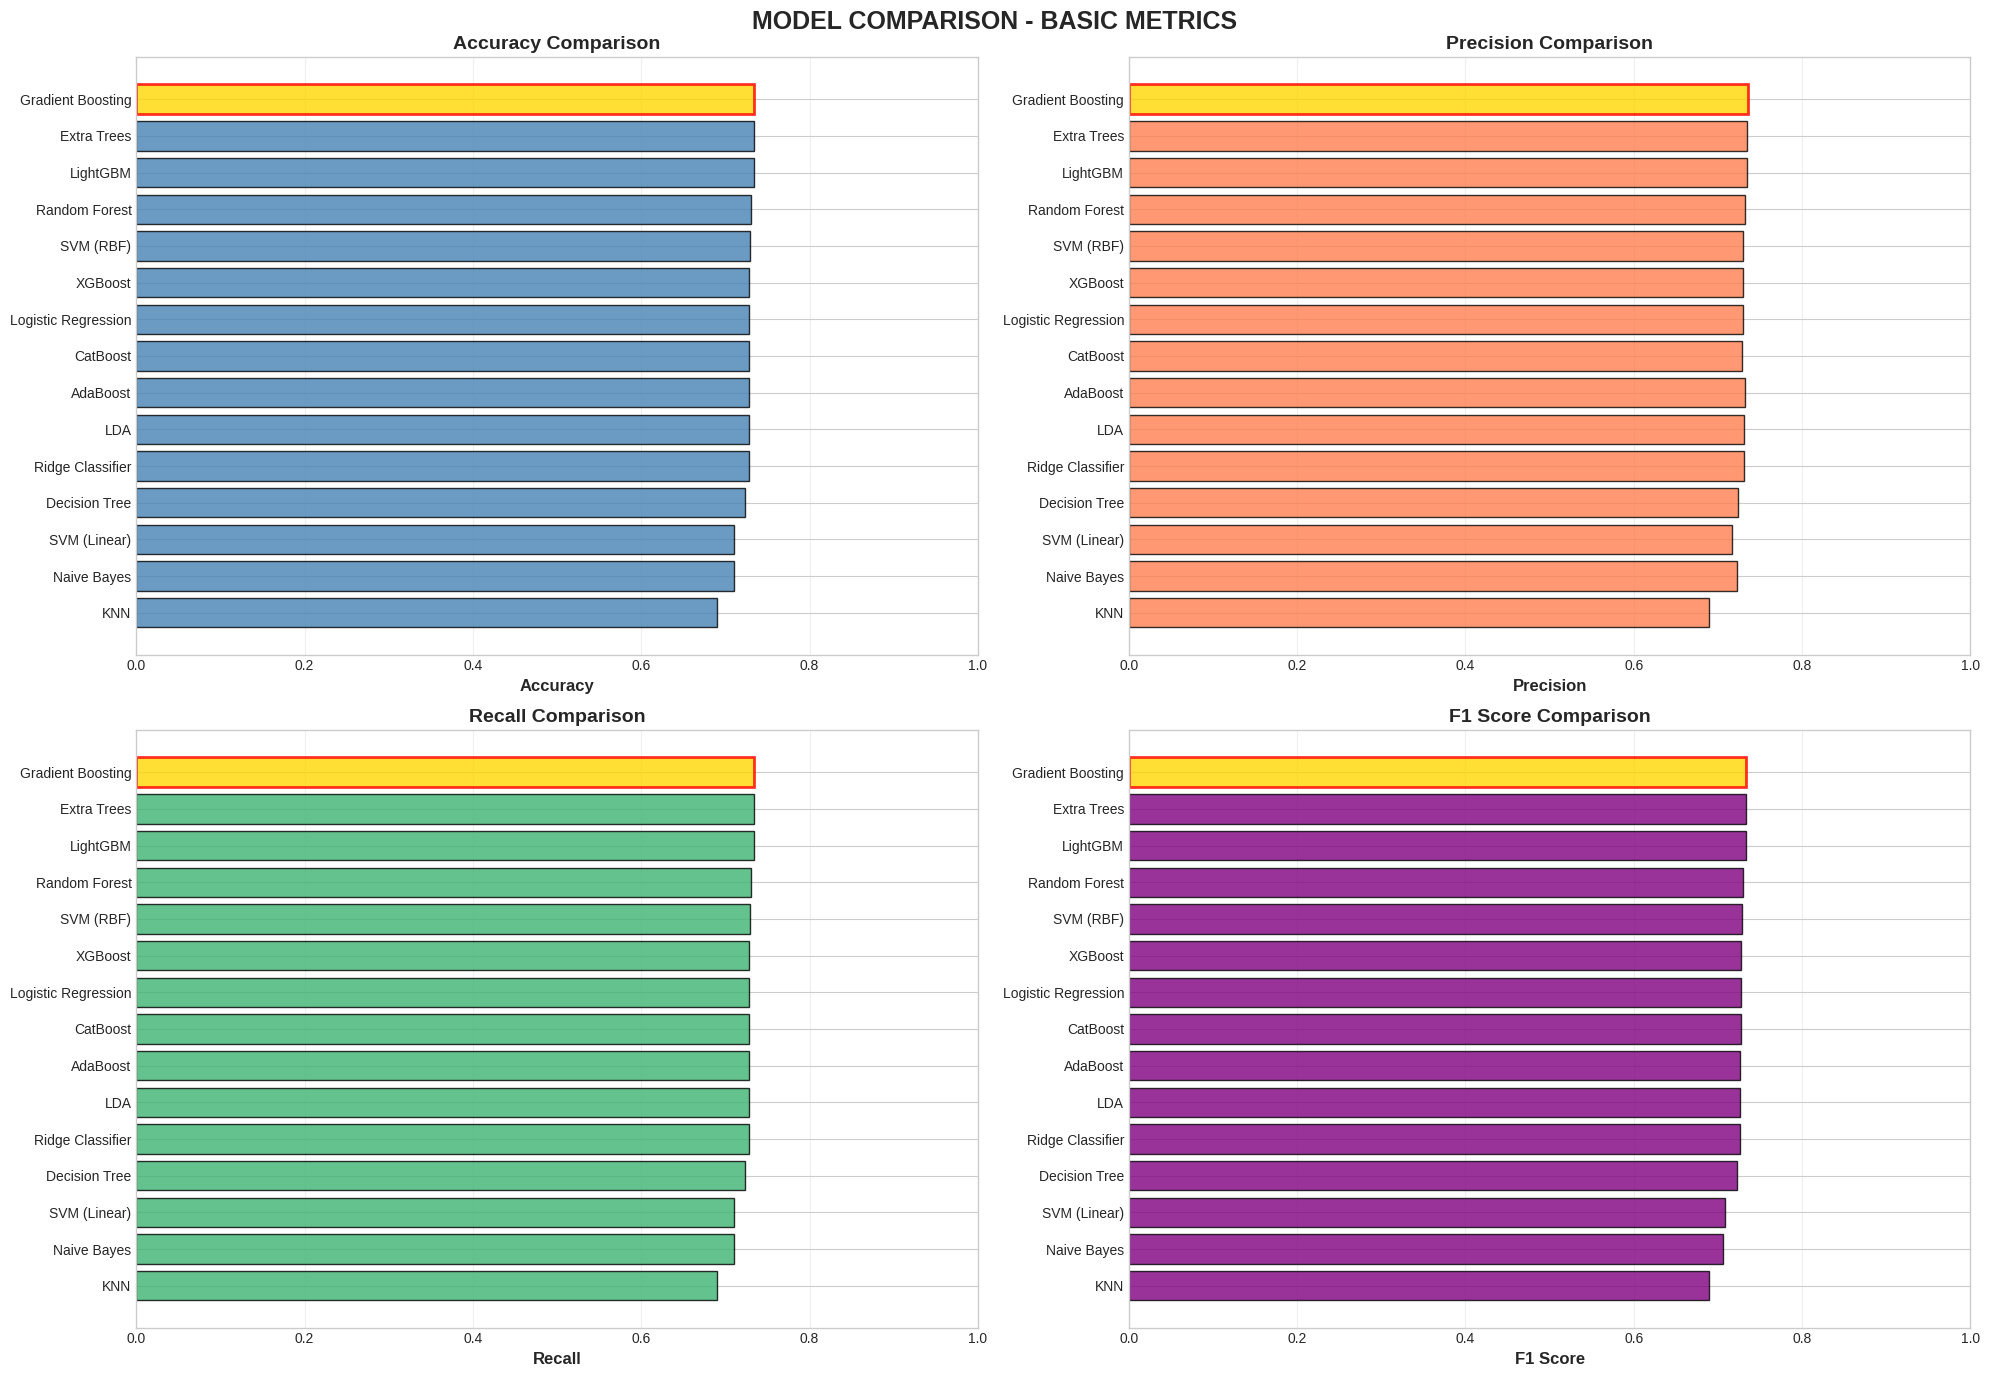

In [23]:
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('MODEL COMPARISON - BASIC METRICS', fontsize=18, fontweight='bold')

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    colors = ['steelblue', 'coral', 'mediumseagreen', 'purple']

    for idx, (metric, color) in enumerate(zip(metrics, colors)):
        ax = axes[idx // 2, idx % 2]
        ax.barh(results_df['Model'], results_df[metric],
               color=color, edgecolor='black', alpha=0.8)
        ax.set_xlabel(metric, fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

        max_idx = results_df[metric].idxmax()
        ax.get_children()[max_idx].set_color('gold')
        ax.get_children()[max_idx].set_edgecolor('red')
        ax.get_children()[max_idx].set_linewidth(2)

    plt.tight_layout()
    plt.show()

### Part 2: Medical Metrics

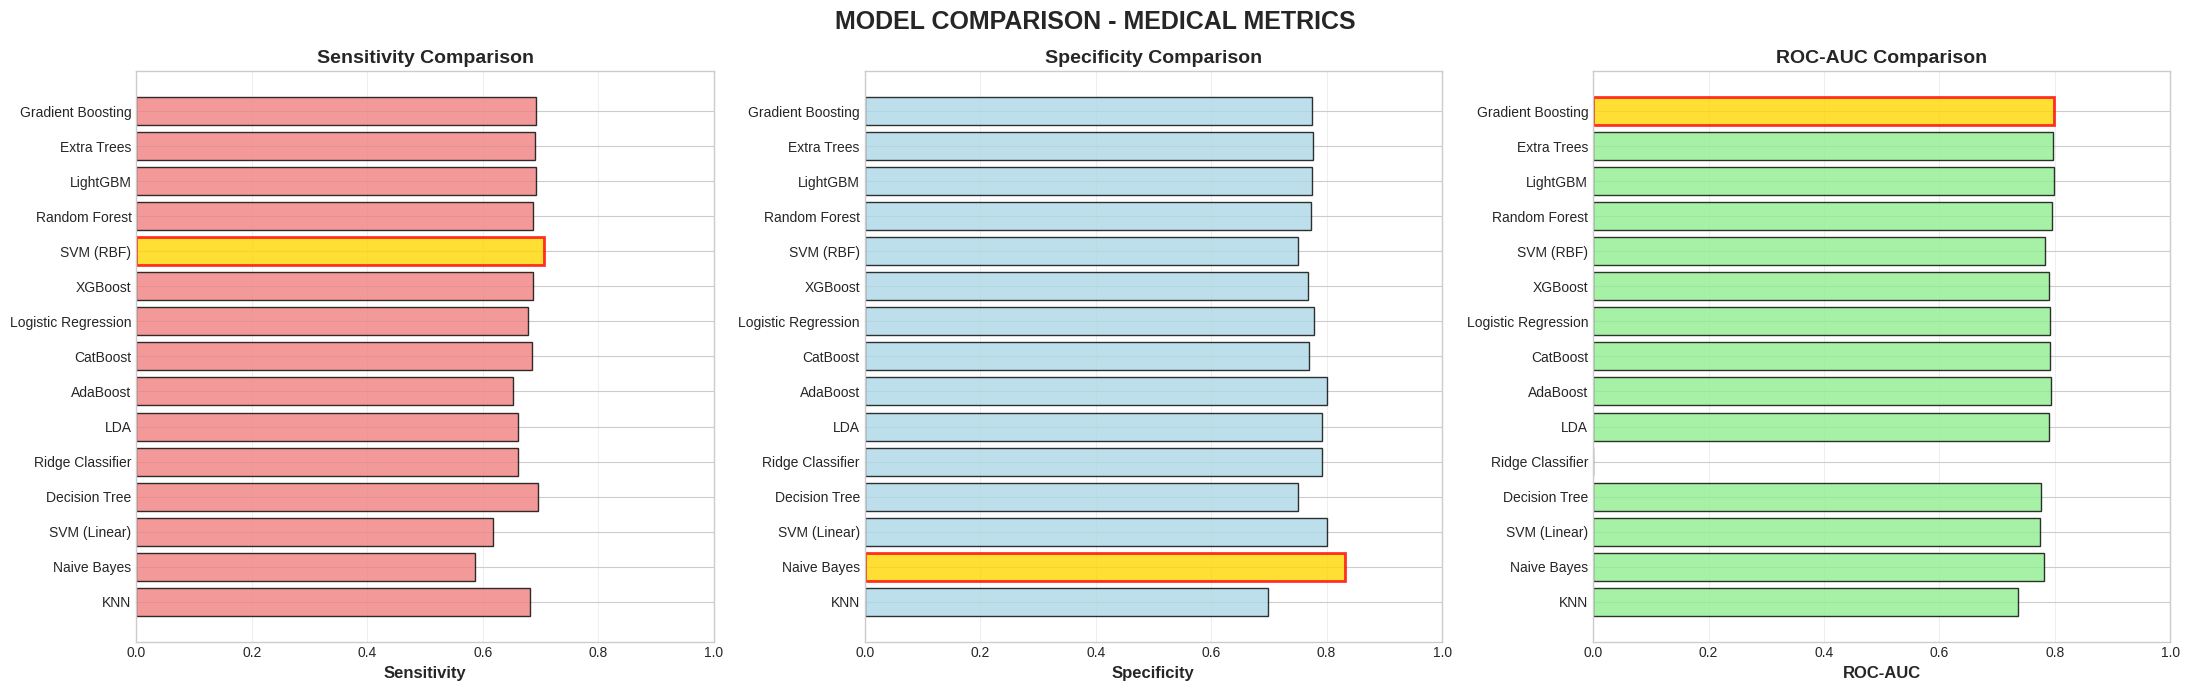

In [24]:
if results:
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    fig.suptitle('MODEL COMPARISON - MEDICAL METRICS', fontsize=18, fontweight='bold')

    medical_metrics = ['Sensitivity', 'Specificity', 'ROC-AUC']
    colors = ['lightcoral', 'lightblue', 'lightgreen']

    for idx, (metric, color) in enumerate(zip(medical_metrics, colors)):
        axes[idx].barh(results_df['Model'], results_df[metric],
                      color=color, edgecolor='black', alpha=0.8)
        axes[idx].set_xlabel(metric, fontsize=12, fontweight='bold')
        axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
        axes[idx].set_xlim(0, 1)
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].invert_yaxis()

        max_idx = results_df[metric].idxmax()
        axes[idx].get_children()[max_idx].set_color('gold')
        axes[idx].get_children()[max_idx].set_edgecolor('red')
        axes[idx].get_children()[max_idx].set_linewidth(2)

    plt.tight_layout()
    plt.show()

### Part 3: Confusion Matrices

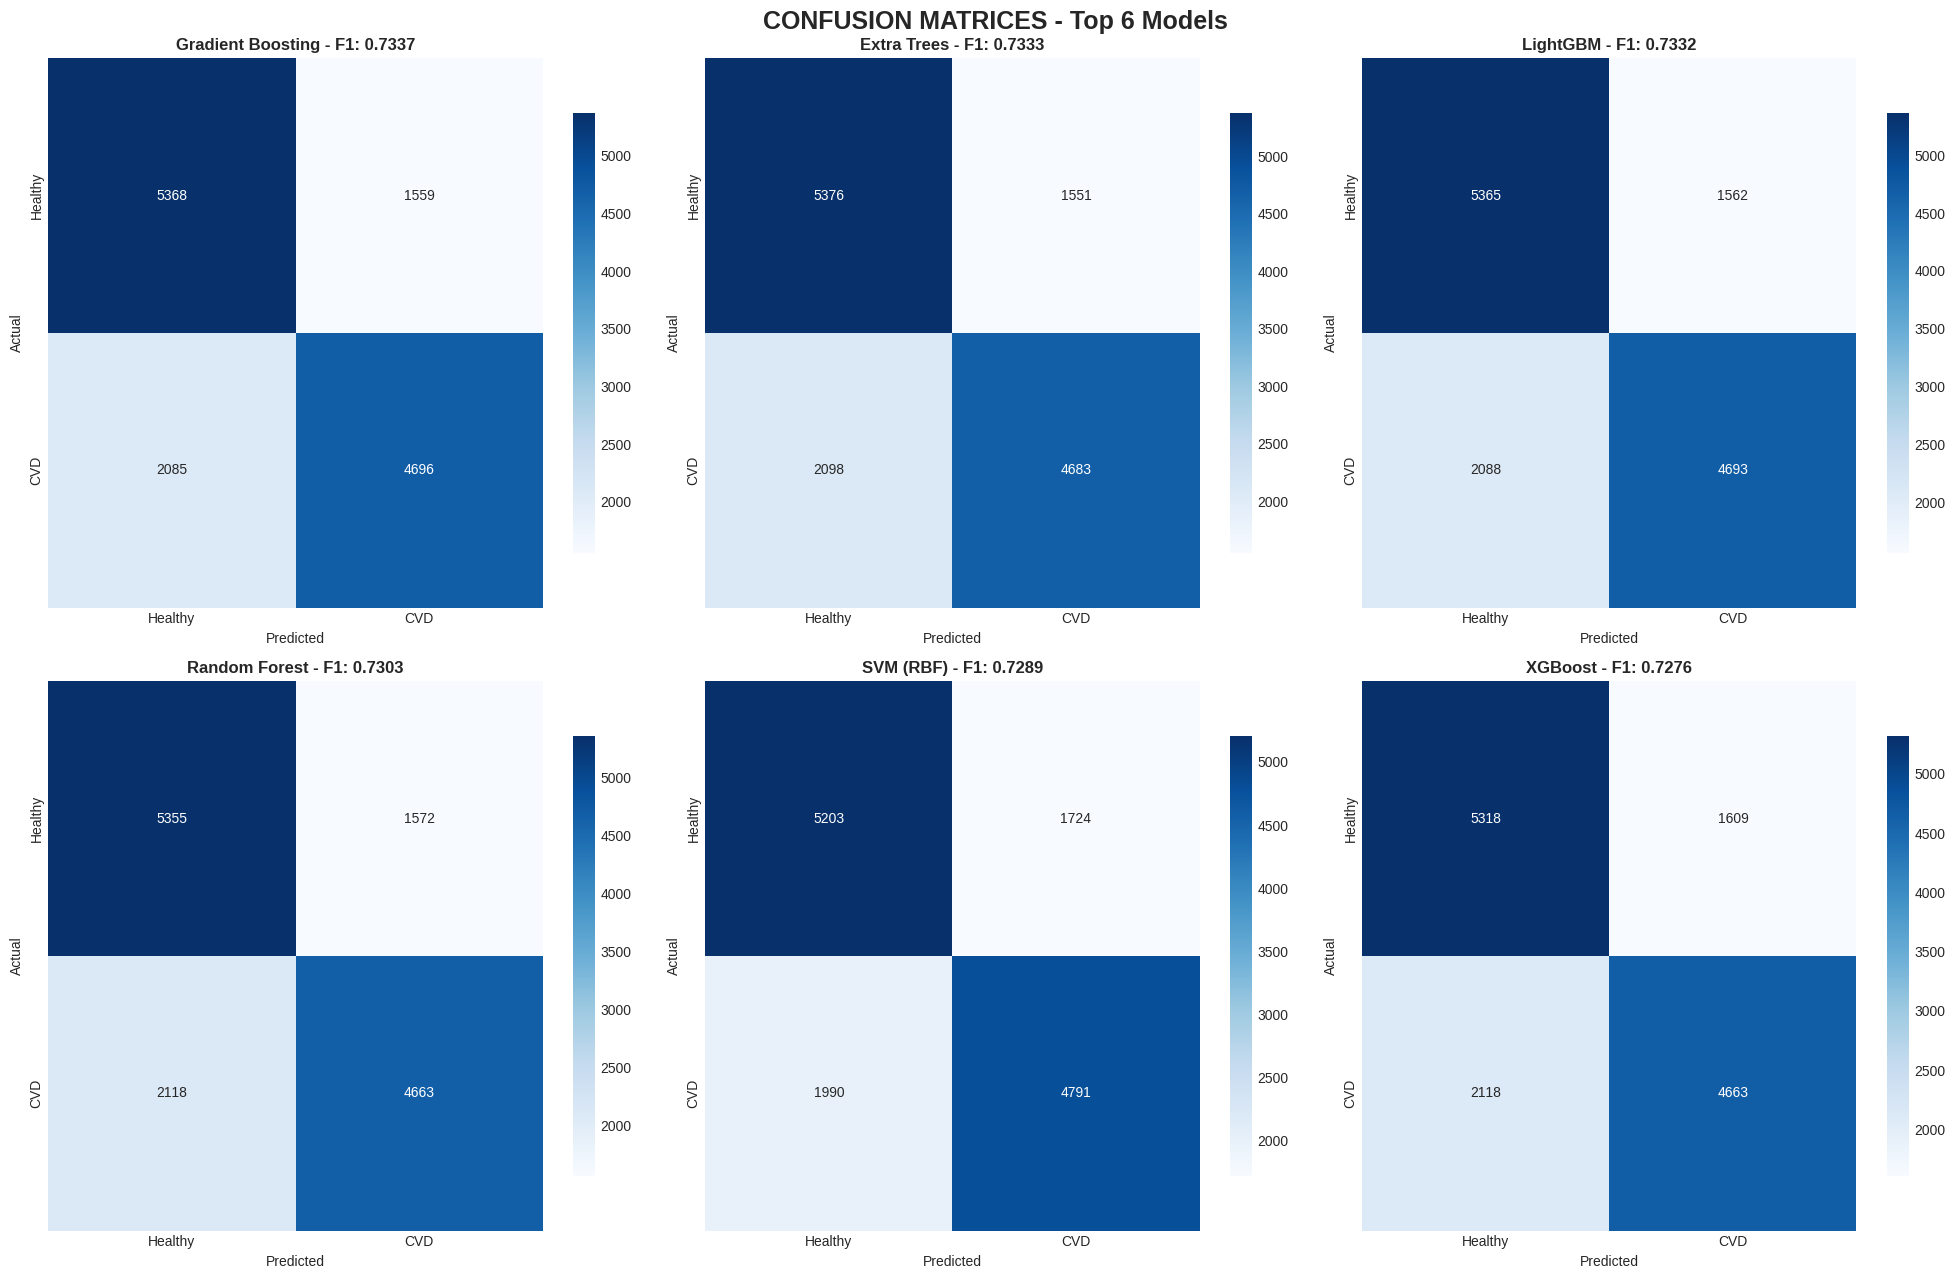

In [25]:
if results and len(results) >= 6:
    top_6 = results_df.head(6)['Model'].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    fig.suptitle('CONFUSION MATRICES - Top 6 Models', fontsize=18, fontweight='bold')

    for idx, model_name in enumerate(top_6):
        ax = axes[idx // 3, idx % 3]
        cm = results[model_name]['confusion_matrix']

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Healthy', 'CVD'],
                   yticklabels=['Healthy', 'CVD'],
                   cbar_kws={'shrink': 0.8})

        ax.set_title(f'{model_name} - F1: {results[model_name]["F1_Score"]:.4f}',
                    fontweight='bold', fontsize=12)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

### Part 4: ROC Curves

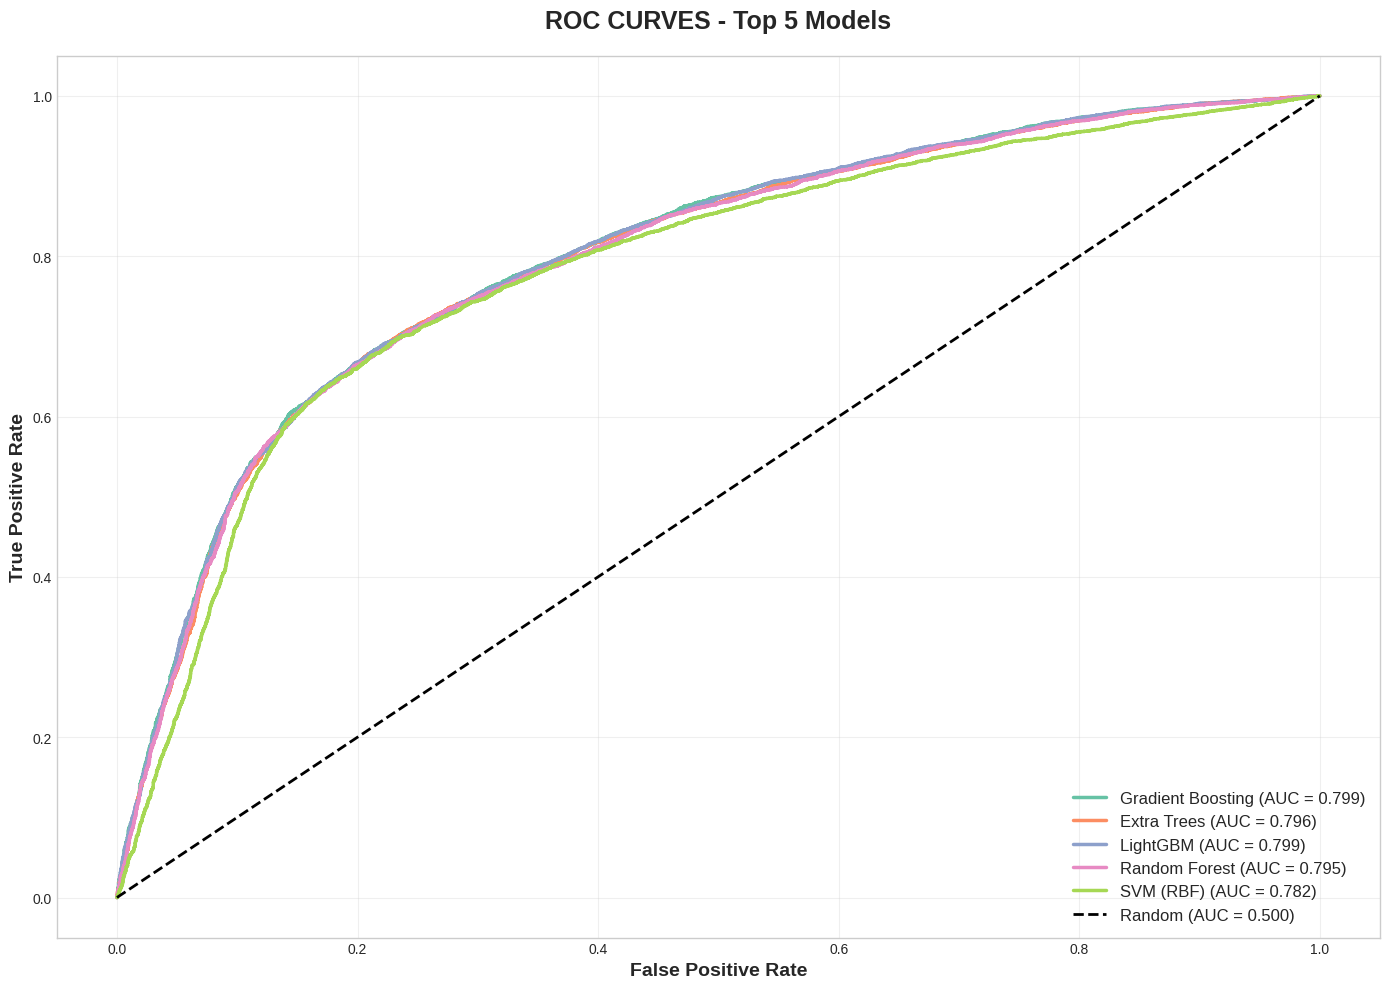

In [26]:
if results:
    top_5 = results_df.head(5)['Model'].tolist()

    plt.figure(figsize=(14, 10))

    for model_name in top_5:
        if results[model_name]['pred_proba'] is not None:
            fpr, tpr, _ = roc_curve(y_test, results[model_name]['pred_proba'])
            roc_auc = results[model_name]['ROC_AUC']
            plt.plot(fpr, tpr, linewidth=2.5,
                    label=f'{model_name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.500)')
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title('ROC CURVES - Top 5 Models', fontsize=18, fontweight='bold', pad=20)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8. CLINICAL INSIGHTS & RECOMMENDATIONS

In [27]:
print('='*100)
print('CARDIOVASCULAR DISEASE PREDICTION - FINAL RESULTS')
print('='*100)

print('\n1. DATASET SUMMARY:')
print(f'   Total Patients: {len(df):,}')
print(f'   Clean Data: {len(df_clean):,}')
print(f'   CVD Rate: {disease_rate:.2f}%')
print(f'   Features: {X.shape[1]}')

if results:
    print('\n2. BEST MODEL:')
    print(f'   Model: {best_model}')
    print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
    print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'   Sensitivity: {results_df.iloc[0]["Sensitivity"]:.4f}')
    print(f'   Specificity: {results_df.iloc[0]["Specificity"]:.4f}')
    print(f'   ROC-AUC: {results_df.iloc[0]["ROC-AUC"]:.4f}')

    print('\n3. TOP 5 MODELS:')
    for idx, row in results_df.head(5).iterrows():
        print(f'   {idx+1}. {row["Model"]:25} F1: {row["F1 Score"]:.4f}, Sens: {row["Sensitivity"]:.4f}')

print('\n4. KEY RISK FACTORS:')
print('   - Blood Pressure (Systolic > 140, Diastolic > 90)')
print('   - BMI (Obesity > 30)')
print('   - Age (Risk increases with age)')
print('   - Cholesterol (High levels)')
print('   - Glucose (High levels)')
print('   - Smoking')

print('\n5. CLINICAL RECOMMENDATIONS:')
print('   - Regular BP monitoring for high-risk patients')
print('   - Weight management programs for BMI > 30')
print('   - Cholesterol and glucose control')
print('   - Smoking cessation programs')
print('   - Physical activity promotion')
print(f'   - Use {best_model} for risk prediction')

print('\n6. MEDICAL METRICS EXPLAINED:')
print('   - Sensitivity: Correctly identifying CVD patients (minimize FN)')
print('   - Specificity: Correctly identifying healthy individuals (minimize FP)')
print('   - For CVD screening, high Sensitivity is critical!')

print('\n7. ANALYSIS SUMMARY:')
print('   - 20+ Medical visualizations')
print('   - Risk factor analysis')
print('   - 15 ML models trained')
print('   - Comprehensive clinical insights')
print('   - Actionable recommendations')

print('\n' + '='*100)
print('CARDIOVASCULAR DISEASE ANALYSIS COMPLETE!')
print('='*100)

CARDIOVASCULAR DISEASE PREDICTION - FINAL RESULTS

1. DATASET SUMMARY:
   Total Patients: 70,000
   Clean Data: 68,537
   CVD Rate: 49.97%
   Features: 25

2. BEST MODEL:
   Model: Gradient Boosting
   Accuracy: 0.7342
   F1 Score: 0.7337
   Sensitivity: 0.6925
   Specificity: 0.7749
   ROC-AUC: 0.7990

3. TOP 5 MODELS:
   1. Gradient Boosting         F1: 0.7337, Sens: 0.6925
   2. Extra Trees               F1: 0.7333, Sens: 0.6906
   3. LightGBM                  F1: 0.7332, Sens: 0.6921
   4. Random Forest             F1: 0.7303, Sens: 0.6877
   5. SVM (RBF)                 F1: 0.7289, Sens: 0.7065

4. KEY RISK FACTORS:
   - Blood Pressure (Systolic > 140, Diastolic > 90)
   - BMI (Obesity > 30)
   - Age (Risk increases with age)
   - Cholesterol (High levels)
   - Glucose (High levels)
   - Smoking

5. CLINICAL RECOMMENDATIONS:
   - Regular BP monitoring for high-risk patients
   - Weight management programs for BMI > 30
   - Cholesterol and glucose control
   - Smoking cessation pro